# Mounting the drive and importing libraries

In [ ]:
# mount drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl
import os
import seaborn as sns
from matplotlib.gridspec import GridSpec
from itertools import product
import scipy.stats as ss
import calendar
from IPython.display import HTML
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.utils import resample
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import PCA
from scipy.stats import randint, uniform
from sklearn.neighbors import LocalOutlierFactor

#Data Understanding and Data Cleaning


##1. Initial Preprocessing steps
Selecting Attributes based on:
* data type
* missing values
* number of distinct values


First we will load the whole dataset from the drive. In the first step we will eliminate the attributes which has more than 50% missing values alongside with the attributes with string data type.

In [ ]:

#Read CSV file from drive
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/Police_Incidents_20241030.csv'
#Check whether the directory exists
#os.path.exists(directory)

df_incident = pd.read_csv(directory)

<ipython-input-75-83b9cc38a111>:6: DtypeWarning: Columns (3,53,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df_incident = pd.read_csv(directory)


In [ ]:

for col in df_incident.columns:
  Nan = df_incident[col].isnull().sum()
  print(f'The Number of missing values in {col} = {Nan}')


The Number of missing values in Incident Number w/year = 0
The Number of missing values in Year of Incident = 0
The Number of missing values in Service Number ID = 0
The Number of missing values in Watch = 0
The Number of missing values in Call (911) Problem = 96239
The Number of missing values in Type of Incident = 3
The Number of missing values in Type  Location = 1357
The Number of missing values in Type of Property = 1027620
The Number of missing values in Incident Address = 3789
The Number of missing values in Apartment Number = 992103
The Number of missing values in Reporting Area = 1017
The Number of missing values in Beat = 751
The Number of missing values in Division = 751
The Number of missing values in Sector = 287
The Number of missing values in Council District = 1586
The Number of missing values in Target Area Action Grids = 819324
The Number of missing values in Community = 1144121
The Number of missing values in Date1 of Occurrence = 0
The Number of missing values in Ye

In [ ]:
#finding the columns with more than 50% missing values of the whole data
Thereshold = df_incident.shape[0] * 0.5
#creating a list of columns with more than 50% of missing values
missing_col = [col for col in df_incident.columns if df_incident[col].isnull().sum()> Thereshold]

In [ ]:
print(Thereshold)
print(missing_col)

641555.0
['Type of Property', 'Apartment Number', 'Target Area Action Grids', 'Community', 'Special Report (Pre-RMS)', 'Responding Officer #2 Badge No', 'Responding Officer #2  Name', 'Hate Crime', 'Hate Crime Description', 'Weapon Used', 'Gang Related Offense', 'UCR Offense Name', 'UCR Offense Description', ' UCR Code', 'Offense Type']


In [ ]:
#Creating a list of colummns with date data type based on column names
date_col = [col for col in df_incident.columns  if 'Date' in col]
date_col

# Convert the columns in date_col to datetime objects
for col in date_col:
  try:
    df_incident[col] = pd.to_datetime(df_incident[col])
  except ValueError:
    print(f"Could not convert {col} to datetime.")

Useful columns are the ones with a data type other than string

In [ ]:

useful_col = ['Watch','Call (911) Problem','Type of Property','Beat','Division','Sector','Council District','Person Involvement Type','Victim Type','Victim Race',
              'Victim Ethnicity','Victim Gender','Investigating Unit 1','Investigating Unit 2','Offense Status','UCR Disposition','Family Offense','Hate Crime',
              'Gang Related Offense','Drug Related Istevencident','Criminal Justice Information Service Code','Penal Code','Offense Type','NIBRS Crime Category',
              'NIBRS Crime Against','NIBRS Code','NIBRS Group','NIBRS Type','Incident Number w/year','Call Cleared Date Time','Call Dispatch Date Time','Zip Code'
              ]

In [ ]:

len(useful_col)

32

In [ ]:
#Deleting the attributes with more than 50% of missing values from the useful columns
for col in missing_col:
  if col in useful_col:
    useful_col.remove(col)
    print(col)


#lengh of useful columns after removing attributes with more than 50% missing values
len(useful_col)


Type of Property
Hate Crime
Gang Related Offense
Offense Type


28

In [ ]:
#deleting the columns with more than 60 distinct values
#creatinh a list with the polynomial attributes with more than 60 distinct values
col_high_distinct= [col for col in useful_col if (df_incident[col].dtype != '<M8[ns]') & (df_incident[col].nunique(dropna= False) > 60)]
print(col_high_distinct)

#deleting the attributes from the dataframe
for col in col_high_distinct:
  useful_col.remove(col)

print(len(useful_col))



['Call (911) Problem', 'Beat', 'Criminal Justice Information Service Code', 'Penal Code', 'Incident Number w/year', 'Zip Code']
22


In [ ]:
#removing the attributes with data quality issues
df_incident.drop(df_incident.columns.difference(useful_col), axis=1, inplace=True)

In [ ]:
for col in df_incident.columns:
  Nan = df_incident[col].isnull().sum()
  print(f'The Number of missing values in {col} = {Nan}')

The Number of missing values in Watch = 0
The Number of missing values in Division = 751
The Number of missing values in Sector = 287
The Number of missing values in Council District = 1586
The Number of missing values in Call Cleared Date Time = 96790
The Number of missing values in Call Dispatch Date Time = 96490
The Number of missing values in Person Involvement Type = 47879
The Number of missing values in Victim Type = 56417
The Number of missing values in Victim Race = 467169
The Number of missing values in Victim Ethnicity = 468571
The Number of missing values in Victim Gender = 470219
The Number of missing values in Investigating Unit 1 = 338777
The Number of missing values in Investigating Unit 2 = 338767
The Number of missing values in Offense Status = 11693
The Number of missing values in UCR Disposition = 11521
The Number of missing values in Family Offense = 95063
The Number of missing values in Drug Related Istevencident = 95192
The Number of missing values in NIBRS Crime 

In [ ]:
df_incident.dropna(inplace=True)

In [ ]:
df_incident.shape

(471643, 22)

In [ ]:
# Save the DataFrame to your Google Drive
save_path = '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_selected.csv'
df_incident.to_csv(save_path, index=False)  # Set index=False to avoid saving the index column

In [ ]:
df_incident.dtypes

,0
Watch,object
Division,object
Sector,float64
Council District,object
Call Cleared Date Time,datetime64[ns]
Call Dispatch Date Time,datetime64[ns]
Person Involvement Type,object
Victim Type,object
Victim Race,object
Victim Ethnicity,object


##2. Preprocessing
* Mapping attributes which have a lot of distinct values
*


Note: we are loading the dataframe with useful columns as the df_incident which is the name that we used for the whole dataset as well so if you are uncommenting the cells note that the names must be modified

In [ ]:
#loading the data set with selected attributes
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_selected.csv'

df_incident = pd.read_csv(directory, index_col= None)

<ipython-input-90-2d961db39d17>:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_incident = pd.read_csv(directory, index_col= None)


Most of the data types are objects so we have to do further proccessing to fix the data types

In [ ]:

df_incident.dtypes

,0
Watch,object
Division,object
Sector,float64
Council District,object
Call Cleared Date Time,object
Call Dispatch Date Time,object
Person Involvement Type,object
Victim Type,object
Victim Race,object
Victim Ethnicity,object


'''
df_incident.dtypes


In [ ]:
#Creating a list of colummns with date data type based on column names
date_col = [col for col in df_incident.columns  if 'Date' in col]
date_col

# Convert the columns in date_col to datetime objects
for col in date_col:
  try:
    df_incident[col] = pd.to_datetime(df_incident[col])
  except ValueError:
    print(f"Could not convert {col} to datetime.")

In [ ]:
#Checking the distinc values of the attributes which do not have a datetime data type
for col in df_incident.columns:
  if df_incident[col].dtype != '<M8[ns]':
    num_distinct_values = df_incident[col].nunique(dropna=False)
    print(f"Column '{col}' has {num_distinct_values} distinct values.")


Column 'Watch' has 7 distinct values.
Column 'Division' has 10 distinct values.
Column 'Sector' has 35 distinct values.
Column 'Council District' has 17 distinct values.
Column 'Person Involvement Type' has 5 distinct values.
Column 'Victim Type' has 6 distinct values.
Column 'Victim Race' has 11 distinct values.
Column 'Victim Ethnicity' has 3 distinct values.
Column 'Victim Gender' has 4 distinct values.
Column 'Investigating Unit 1' has 5 distinct values.
Column 'Investigating Unit 2' has 56 distinct values.
Column 'Offense Status' has 6 distinct values.
Column 'UCR Disposition' has 9 distinct values.
Column 'Family Offense' has 1 distinct values.
Column 'Drug Related Istevencident' has 3 distinct values.
Column 'NIBRS Crime Category' has 31 distinct values.
Column 'NIBRS Crime Against' has 5 distinct values.
Column 'NIBRS Code' has 48 distinct values.
Column 'NIBRS Group' has 3 distinct values.
Column 'NIBRS Type' has 13 distinct values.


In [ ]:

# Rounding data time into minutes
for column in df_incident.columns:
  if pd.api.types.is_datetime64_any_dtype(df_incident[column]):
    df_incident[column] = df_incident[column].dt.round('min')

In [ ]:
#Class attributes distinct values
df_incident['UCR Disposition'].nunique()

9

In [ ]:
df_incident['Investigating Unit 2'].unique()

array(['Property Crime Division / NE Property Crimes',
       'South Central / South Central Patrol', 'Capers / Assaults',
       'Property Crime Division / SW Property Crimes',
       'Property Crime Division / NC Property Crimes',
       'Special Investigations / Auto Theft', 'Capers / Robbery',
       'Field Services / Vehicle Crimes Unit',
       'Property Crime Division / NW Property Crimes',
       'Property Crime Division / SE Property Crimes',
       'Property Crime Division / SC Property Crimes',
       'Property Crime Division / CE Property Crimes',
       'Capers / Homicide', 'Capers / Family Violence',
       'Special Investigations / Financial Crimes',
       'Comp Stat Division / Gang', 'Capers / SIU',
       'Capers / Phote Line up', 'Intelligence / Intelligence',
       'Support Division / Legal', 'SouthEast / SouthEast Patrol',
       'Central / Central Patrol', 'Misc Divisions / MISC Personnel',
       'Marshalls / Marshall Inv', 'Capers / Child Exploitation',
       

##Mapping



In [ ]:

# #mapping Offense status
# OffenseMap = {'Offense Status': ['Suspended', 'Clear by Arrest', 'Clear by Exceptional Arrest',
#                                  'Open', 'Closed/Cleared', 'nan', 'Returned for Correction', 'L']}

# Defining the mapping dictionary for new categories
status_mapping = {
    'Suspended': 'Suspended',
    'Clear by Arrest': 'Resolved',
    'Clear by Exceptional Arrest': 'Resolved',
    'Open': 'Pending',
    'Closed/Cleared': 'Resolved',
    'nan': 'Nan',
    'Returned for Correction': 'Pending',
    'L': 'Suspended'
}

# Appling the mapping
df_incident['Offense Status'] = df_incident['Offense Status'].map(status_mapping)



In [ ]:
df_incident['Offense Status'].unique()

array(['Suspended', 'Resolved', 'Pending'], dtype=object)

In [ ]:
df_incident['NIBRS Crime Category'].unique()

array(['LARCENY/ THEFT OFFENSES', 'ASSAULT OFFENSES',
       'DESTRUCTION/ DAMAGE/ VANDALISM OF PROPERTY',
       'MOTOR VEHICLE THEFT', 'ROBBERY', 'MISCELLANEOUS',
       'TRAFFIC VIOLATION - HAZARDOUS', 'BURGLARY/ BREAKING & ENTERING',
       'ALL OTHER OFFENSES', 'TRESPASS OF REAL PROPERTY',
       'FRAUD OFFENSES', 'KIDNAPPING/ ABDUCTION', 'HOMICIDE OFFENSES',
       'COUNTERFEITING / FORGERY', 'EXTORTION/ BLACKMAIL', 'EMBEZZELMENT',
       'DISORDERLY CONDUCT', 'FAMILY OFFENSES, NONVIOLENT',
       'DRUG/ NARCOTIC VIOLATIONS', 'ARSON', 'WEAPON LAW VIOLATIONS',
       'DRIVING UNDER THE INFLUENCE', 'STOLEN PROPERTY OFFENSES',
       'ANIMAL OFFENSES', 'PUBLIC INTOXICATION',
       'TRAFFIC VIOLATION - NON HAZARDOUS', 'LIQUOR LAW VIOLATIONS',
       'PEEPING TOM', 'BRIBERY', 'PORNOGRAPHY/ OBSCENE MATERIAL',
       'HUMAN TRAFFICKING'], dtype=object)

In [ ]:
#mapping NIBRS Crime category
'''
#Trial Do not read
CategoryMap = {'NIBRS Crime Category': ['MOTOR VEHICLE THEFT', 'LARCENY/ THEFT OFFENSES', 'MISCELLANEOUS',
       'ASSAULT OFFENSES', 'BURGLARY/ BREAKING & ENTERING',
       'DESTRUCTION/ DAMAGE/ VANDALISM OF PROPERTY', 'FRAUD OFFENSES',
       'ALL OTHER OFFENSES', 'TRESPASS OF REAL PROPERTY',
       'FAMILY OFFENSES, NONVIOLENT', 'TRAFFIC VIOLATION - HAZARDOUS',
       'ROBBERY', 'HOMICIDE OFFENSES', 'STOLEN PROPERTY OFFENSES',
       'COUNTERFEITING / FORGERY', 'ANIMAL OFFENSES',
       'KIDNAPPING/ ABDUCTION', 'PUBLIC INTOXICATION',
       'DRUG/ NARCOTIC VIOLATIONS', 'EMBEZZELMENT', 'DISORDERLY CONDUCT',
       'EXTORTION/ BLACKMAIL', 'DRIVING UNDER THE INFLUENCE',
       'WEAPON LAW VIOLATIONS', 'ARSON',
       'TRAFFIC VIOLATION - NON HAZARDOUS', 'LIQUOR LAW VIOLATIONS',
       'PEEPING TOM', 'BRIBERY', 'PORNOGRAPHY/ OBSCENE MATERIAL',
       'HUMAN TRAFFICKING']}
df = pd.DataFrame(CategoryMap)
'''

# Defining the mapping dictionary for new categories
CrimeMapCategory = {'MOTOR VEHICLE THEFT' : 'Theft and Property Crimes',
                    'LARCENY/ THEFT OFFENSES' : 'Theft and Property Crimes',
                    'BURGLARY/ BREAKING & ENTERING' : 'Theft and Property Crimes',
                    'ROBBERY' : 'Theft and Property Crimes',
                    'FRAUD OFFENSES' : 'Theft and Property Crimes',
                    'COUNTERFEITING / FORGERY' : 'Theft and Property Crimes',
                    'EMBEZZELMENT' : 'Theft and Property Crimes',
                    'STOLEN PROPERTY OFFENSES' : 'Theft and Property Crimes',

                    'ASSAULT OFFENSES' : 'Violent Crimes and Assaults',
                    'KIDNAPPING/ ABDUCTION' : 'Violent Crimes and Assaults',
                    'HOMICIDE OFFENSES' : 'Violent Crimes and Assaults',
                    'ARSON' : 'Violent Crimes and Assaults',

                    'DESTRUCTION/ DAMAGE/ VANDALISM OF PROPERTY': 'Property Damage and Trespass',
                    'TRESPASS OF REAL PROPERTY': 'Property Damage and Trespass',

                    'DRUG/ NARCOTIC VIOLATIONS' : 'Drug and Alcohol Offenses',
                    'LIQUOR LAW VIOLATIONS' : 'Drug and Alcohol Offenses',
                    'PUBLIC INTOXICATION' : 'Drug and Alcohol Offenses',
                    'DRIVING UNDER THE INFLUENCE' : 'Drug and Alcohol Offenses',

                    'DISORDERLY CONDUCT': 'Public Order and Safety Violations',
                    'TRAFFIC VIOLATION - HAZARDOUS' : 'Public Order and Safety Violations',
                    'TRAFFIC VIOLATION - NON HAZARDOUS' : 'Public Order and Safety Violations',
                    'FAMILY OFFENSES, NONVIOLENT' : 'Public Order and Safety Violations',
                    'ANIMAL OFFENSES' : 'Public Order and Safety Violations',
                    'PEEPING TOM' : 'Public Order and Safety Violations',
                    'BRIBERY' : 'Public Order and Safety Violations',

                    'WEAPON LAW VIOLATIONS' : 'Weapons and Other Regulatory Violations',
                    'PORNOGRAPHY/ OBSCENE MATERIAL' : 'Weapons and Other Regulatory Violations',

                    'HUMAN TRAFFICKING' : 'Specialized Offenses',
                    'EXTORTION/ BLACKMAIL' : 'Specialized Offenses',

                    'MISCELLANEOUS' :  'Miscellaneous',
                    'ALL OTHER OFFENSES' :  'Miscellaneous'
                     }

# Appling mapping
df_incident['NIBRS Crime Category'] = df_incident['NIBRS Crime Category'].map(CrimeMapCategory)



In [ ]:
'''
#Debugging purposes Do not read
for i in df_incident['NIBRS Crime Category'].unique():
  if i not in CrimeMapCategory.keys():
    print(i)
'''

"\n#Debugging purposes Do not read\nfor i in df_incident['NIBRS Crime Category'].unique():\n  if i not in CrimeMapCategory.keys():\n    print(i)\n"

In [ ]:
df_incident['NIBRS Crime Category'].unique()

array(['Theft and Property Crimes', 'Violent Crimes and Assaults',
       'Property Damage and Trespass', 'Miscellaneous',
       'Public Order and Safety Violations', 'Specialized Offenses',
       'Drug and Alcohol Offenses',
       'Weapons and Other Regulatory Violations'], dtype=object)

In [ ]:
df_incident['Investigating Unit 2'].unique()

array(['Property Crime Division / NE Property Crimes',
       'South Central / South Central Patrol', 'Capers / Assaults',
       'Property Crime Division / SW Property Crimes',
       'Property Crime Division / NC Property Crimes',
       'Special Investigations / Auto Theft', 'Capers / Robbery',
       'Field Services / Vehicle Crimes Unit',
       'Property Crime Division / NW Property Crimes',
       'Property Crime Division / SE Property Crimes',
       'Property Crime Division / SC Property Crimes',
       'Property Crime Division / CE Property Crimes',
       'Capers / Homicide', 'Capers / Family Violence',
       'Special Investigations / Financial Crimes',
       'Comp Stat Division / Gang', 'Capers / SIU',
       'Capers / Phote Line up', 'Intelligence / Intelligence',
       'Support Division / Legal', 'SouthEast / SouthEast Patrol',
       'Central / Central Patrol', 'Misc Divisions / MISC Personnel',
       'Marshalls / Marshall Inv', 'Capers / Child Exploitation',
       

In [ ]:

'''
#Trial Do not read
Investigation2 = {'Investigating Unit 2': ['Special Investigations / Auto Theft',
       'Property Crime Division / NC Property Crimes',
       'Special Investigations / Financial Crimes', 'Capers / Assaults',
       'Property Crime Division / CE Property Crimes',
       'Property Crime Division / NW Property Crimes',
       'Property Crime Division / SW Property Crimes',
       'Property Crime Division / SC Property Crimes',
       'Property Crime Division / NE Property Crimes',
       'Property Crime Division / SE Property Crimes',
       'Field Services / Vehicle Crimes Unit',
       'South Central / South Central Patrol', 'Capers / Homicide',
       'Capers / Robbery', 'Capers / Family Violence',
       'Capers / Child Exploitation', 'Capers / Youth Services',
       'Capers / Phote Line up', 'SouthEast / SouthEast Patrol',
       'Support Division / Legal', 'Comp Stat Division / Gang',
       'North Central / North Central Patrol',
       'Intelligence / Intelligence',
       'Support Division / Detention Services',
       'Field Services / Traffic',
       'Crime Response Team / SW Crime Response Team',
       'NorthEast / NorthEast Patrol', 'Narcotics / Vice', 'CBD / CBD',
       'Public Integrity / Public Integrity',
       'Misc Divisions / MISC Personnel',
       'Crime Response Team / NW Crime Response Team',
       'Marshalls / Marshall Inv', 'Narcotics / Narcotics',
       'Fugitive / Fugitive', 'SouthWest / SouthWest Patrol',
       'Central / Central Patrol', 'Support Division / Property Room',
       'Property Crime Division / Major Crimes', 'Arson / Arson Inv',
       'Field Services / Special Ops', 'Fugitive / Gang Knock and Talk',
       'NorthWest / NorthWest Patrol', 'Capers / Missing Persons',
       'Support Division / Alarm', 'Fugitive / NE PSN Federal Taskforce',
       'Abatement / Abatement', 'Capers / CSRU',
       'Capers / Internet Crime Against Children', 'Capers / SIU',
       'Capers / COST', 'Misc Divisions / Crisis Intervention',
       'Capers / S.O.A.P', 'CBD / Central Patrol', 'Central / CBD',
       'Crime Response Team / NE Crime Response Team']}
df = pd.DataFrame(Investigation2)
'''


#Defining the mapping dictionary for new categories

Investigation2Map = {'Property Crime Division / NE Property Crimes' : 'Property Crime',
      'Property Crime Division / NC Property Crimes' : 'Property Crime',
      'Property Crime Division / CE Property Crimes': 'Property Crime',
      'Property Crime Division / SW Property Crimes': 'Property Crime',
      'Property Crime Division / NW Property Crimes': 'Property Crime',
      'Property Crime Division / SC Property Crimes': 'Property Crime',
      'Property Crime Division / SE Property Crimes': 'Property Crime',
      'Property Crime Division / Major Crimes': 'Property Crime',
      'Property Crime Division / SW Property Crimes': 'Property Crime',

      'South Central / South Central Patrol' : 'Patrol Divisions',
      'North Central / North Central Patrol' : 'Patrol Divisions',
      'NorthEast / NorthEast Patrol' : 'Patrol Divisions',
      'SouthEast / SouthEast Patrol' : 'Patrol Divisions',
      'Central / Central Patrol' : 'Patrol Divisions',
      'SouthWest / SouthWest Patrol' : 'Patrol Divisions',
      'NorthWest / NorthWest Patrol' : 'Patrol Divisions',
      'Central / CBD' : 'Patrol Divisions',
      'CBD / CBD' : 'Patrol Divisions',
      'CBD / Central Patrol' : 'Patrol Divisions',

      'Field Services / Vehicle Crimes Unit': 'Field Services',
      'Field Services / Traffic' : 'Field Services',
      'Field Services / Special Ops' : 'Field Services',

      'Crime Response Team / NW Crime Response Team' : 'Crime Response Teams',
      'Crime Response Team / NE Crime Response Team' : 'Crime Response Teams',
      'Crime Response Team / SW Crime Response Team' : 'Crime Response Teams',
      'Crime Response Team / SE Crime Response Team' : 'Crime Response Teams',

      'Support Division / Property Room' : 'Support Divisions',
      'Support Division / Legal' : 'Support Divisions',
      'Support Division / Detention Services' : 'Support Divisions',
      'Support Division / Alarm' : 'Support Divisions',

      'Misc Divisions / MISC Personnel' : 'Misc Divisions',
      'Misc Divisions / Crisis Intervention' : 'Misc Divisions',
      'Abatement / Abatement' : 'Misc Divisions',

      'Comp Stat Division / Gang' : 'Gang and Fugitive Operations',
      'Fugitive / Gang Knock and Talk' : 'Gang and Fugitive Operations',

      'Special Investigations / Financial Crimes' : 'Special Investigations',
      'Special Investigations / Auto Theft' : 'Special Investigations',
      'Narcotics / Narcotics' : 'Special Investigations',
      'Narcotics / Vice' : 'Special Investigations',
      'Capers / Internet Crime Against Children' : 'Special Investigations',
      'Capers / Child Exploitation' : 'Special Investigations',
      'Capers / Missing Persons' : 'Special Investigations',
      'Intelligence / Intelligence' : 'Special Investigations',
      'Public Integrity / Public Integrity' : 'Special Investigations',
      'Arson / Arson Inv' : 'Special Investigations',
      'Fugitive / Fugitive' : 'Special Investigations',
      'Fugitive / NE PSN Federal Taskforce' : 'Special Investigations',
      'Marshalls / Marshall Inv' : 'Special Investigations',

      'Capers / Assaults' : 'Violent Crimes and Assaults',
      'Capers / Homicide' : 'Violent Crimes and Assaults',
      'Capers / Robbery' : 'Violent Crimes and Assaults',
      'Capers / Family Violence' : 'Violent Crimes and Assaults',
      'Capers / Youth Services' : 'Violent Crimes and Assaults',
      'Capers / Phote Line up' : 'Violent Crimes and Assaults',
      'Capers / SIU' : 'Violent Crimes and Assaults',
      'Capers / COST' : 'Violent Crimes and Assaults',
      'Capers / CSRU' : 'Violent Crimes and Assaults',
      'Capers / Auto Theft' : 'Violent Crimes and Assaults',
      'Capers / S.O.A.P' : 'Violent Crimes and Assaults'
}
#applying mapping
df_incident['Investigating Unit 2'] = df_incident['Investigating Unit 2'].map(Investigation2Map)


In [ ]:
df_incident['Investigating Unit 2'].unique()

array(['Property Crime', 'Patrol Divisions',
       'Violent Crimes and Assaults', 'Special Investigations',
       'Field Services', 'Gang and Fugitive Operations',
       'Support Divisions', 'Misc Divisions', 'Crime Response Teams'],
      dtype=object)

In [ ]:
df_incident['UCR Disposition'].nunique()

9

In [ ]:
'''
#Trial Do not read
#mapping UCR Disposition
UCR_map = {'UCR Disposition':['Suspended', 'Closed', 'CBA (Over Age 17)', 'CBEA (Over Age 17)',
       'Open', 'CBEA (Age 17)', 'CBEA (Under Age 17)', 'CBA (Age 17)',
       'CBA (Under 17)']}

df = pd.DataFrame(UCR_map)
'''

#Defining the mapping dictionary for new categories

UCR_mapping_disposition = { 'Suspended': 'Suspended',
    'Closed': 'Resolved',
    'CBA (Over Age 17)': 'Resolved',
    'CBEA (Over Age 17)': 'Resolved',
    'Open': 'Pending',
    'CBEA (Age 17)': 'Resolved',
    'CBEA (Under Age 17)': 'Resolved',
    'CBA (Age 17)': 'Resolved',
    'CBA (Under 17)': 'Resolved',}

#applying mapping
df_incident['UCR Disposition'] = df_incident['UCR Disposition'].map(UCR_mapping_disposition)



In [ ]:
df_incident['UCR Disposition'].unique()

array(['Suspended', 'Resolved', 'Pending'], dtype=object)

In [ ]:
df_incident['Watch'].unique()

array(['1', '2', '3', 'U', 3, 1, 2], dtype=object)

In [ ]:
'''
#Trial Do not read
#mapping watch
watch_map = {'Watch':['2', '3', '1', 'U', 1, 3, 2]}

df = pd.DataFrame(watch_map)
'''

#Defining the mapping dictionary for new categories

watch_mapping = {'2': 'Watch 2','3': 'Watch 3','1': 'Watch 1','U': 'Watch Unknown',1: 'Watch 1',3: 'Watch 3',  2: 'Watch 2'}

#applying mapping
df_incident['Watch'] = df_incident['Watch'].map(watch_mapping)



In [ ]:
df_incident['Watch'].unique()

array(['Watch 1', 'Watch 2', 'Watch 3', 'Watch Unknown'], dtype=object)

In [ ]:
df_incident['Division'].unique()

array(['NORTHEAST', 'SOUTHEAST', 'NORTHWEST', 'SOUTHWEST',
       'NORTH CENTRAL', 'CENTRAL', 'SOUTH CENTRAL', 'NorthEast',
       'North Central', 'SouthEast'], dtype=object)

In [ ]:
'''
#Trial Do not read
#mapping division
division_map = {'Division':['SOUTH CENTRAL', 'NORTH CENTRAL', 'CENTRAL', 'NORTHWEST',
       'NORTHEAST', 'SOUTHWEST', 'SOUTHEAST', 'NorthEast', 'SouthEast',
       'North Central']}

df = pd.DataFrame(division_map)
'''
#Defining the mapping dictionary for new categories

division_mapping = {'SOUTH CENTRAL': 'South', 'NORTH CENTRAL': 'North', 'CENTRAL': 'Central', 'NORTHWEST': 'North',
       'NORTHEAST': 'North', 'SOUTHWEST': 'South', 'SOUTHEAST': 'South', 'NorthEast': 'North', 'SouthEast': 'South',
       'North Central': 'North'}

#applying mapping
df_incident['Division'] = df_incident['Division'].map(division_mapping)


In [ ]:
df_incident['Division'].unique()

array(['North', 'South', 'Central'], dtype=object)

In [ ]:
df_incident.nunique()

,0
Watch,4
Division,3
Sector,35
Council District,17
Call Cleared Date Time,367666
Call Dispatch Date Time,364322
Person Involvement Type,5
Victim Type,6
Victim Race,11
Victim Ethnicity,3


In [ ]:
#Saving dataset after mapping
save_path = '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_mapped.csv'
df_incident.to_csv(save_path, index=False)  # Set index=False to avoid saving the index column

##Data Visualization


In [ ]:
#Upload the data frame
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_mapped.csv'

df_incident = pd.read_csv(directory, index_col= None)

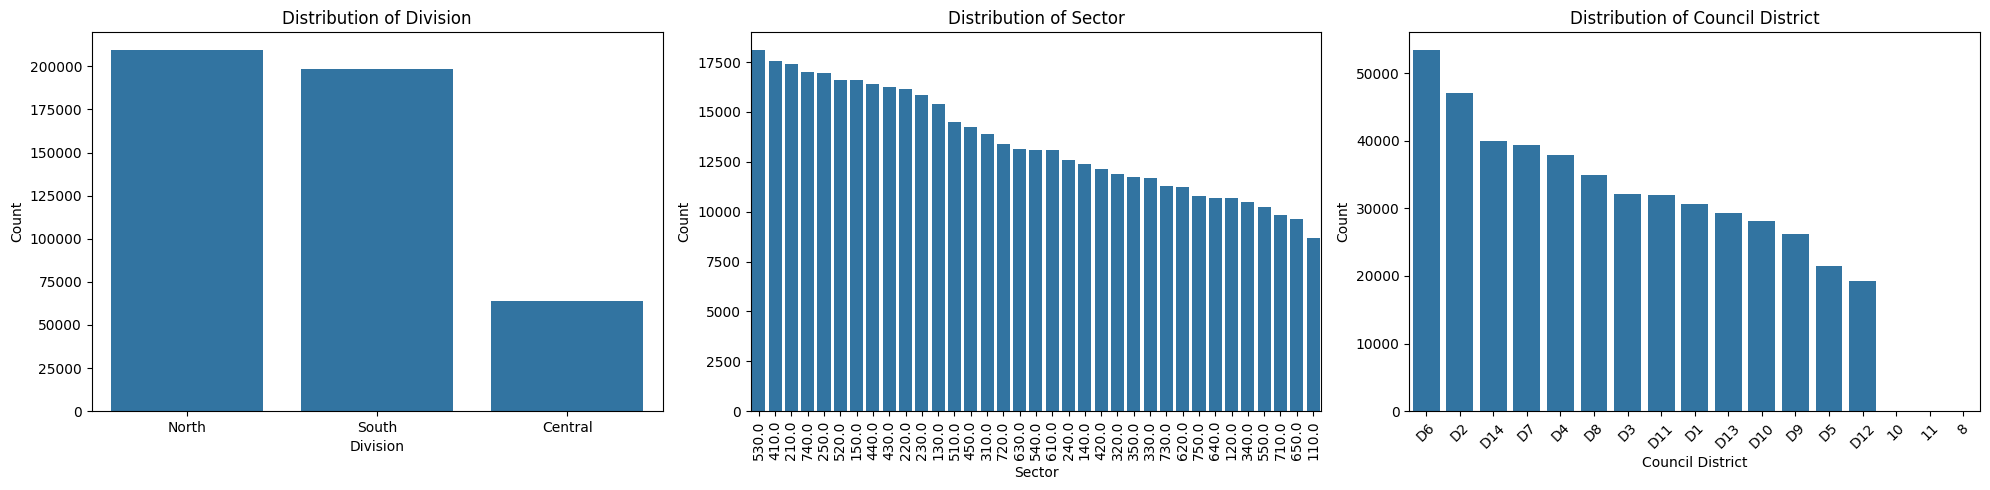

In [ ]:
#Plotting attributes with the location data (Division, Sector, Council district)
#We used subplot to plot all of them in a row
plt.figure(figsize=(20, 5))

#Plotting Division
plt.subplot(1, 3, 1)
sns.countplot(x='Division', data=df_incident, order=df_incident['Division'].value_counts().index)
plt.title("Distribution of Division")
plt.xlabel("Division")
plt.ylabel("Count")

#Plotting Sector
plt.subplot(1, 3, 2)
sns.countplot(x='Sector', data=df_incident, order=df_incident['Sector'].value_counts().index)
plt.title("Distribution of Sector")
plt.xlabel("Sector")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.tight_layout()

#Plotting Council District
plt.subplot(1, 3, 3)
sns.countplot(x='Council District', data=df_incident, order=df_incident['Council District'].value_counts().index)
plt.title("Distribution of Council District")
plt.xlabel("Council District")
plt.xticks(rotation=45)
plt.ylabel("Count")

plt.show()

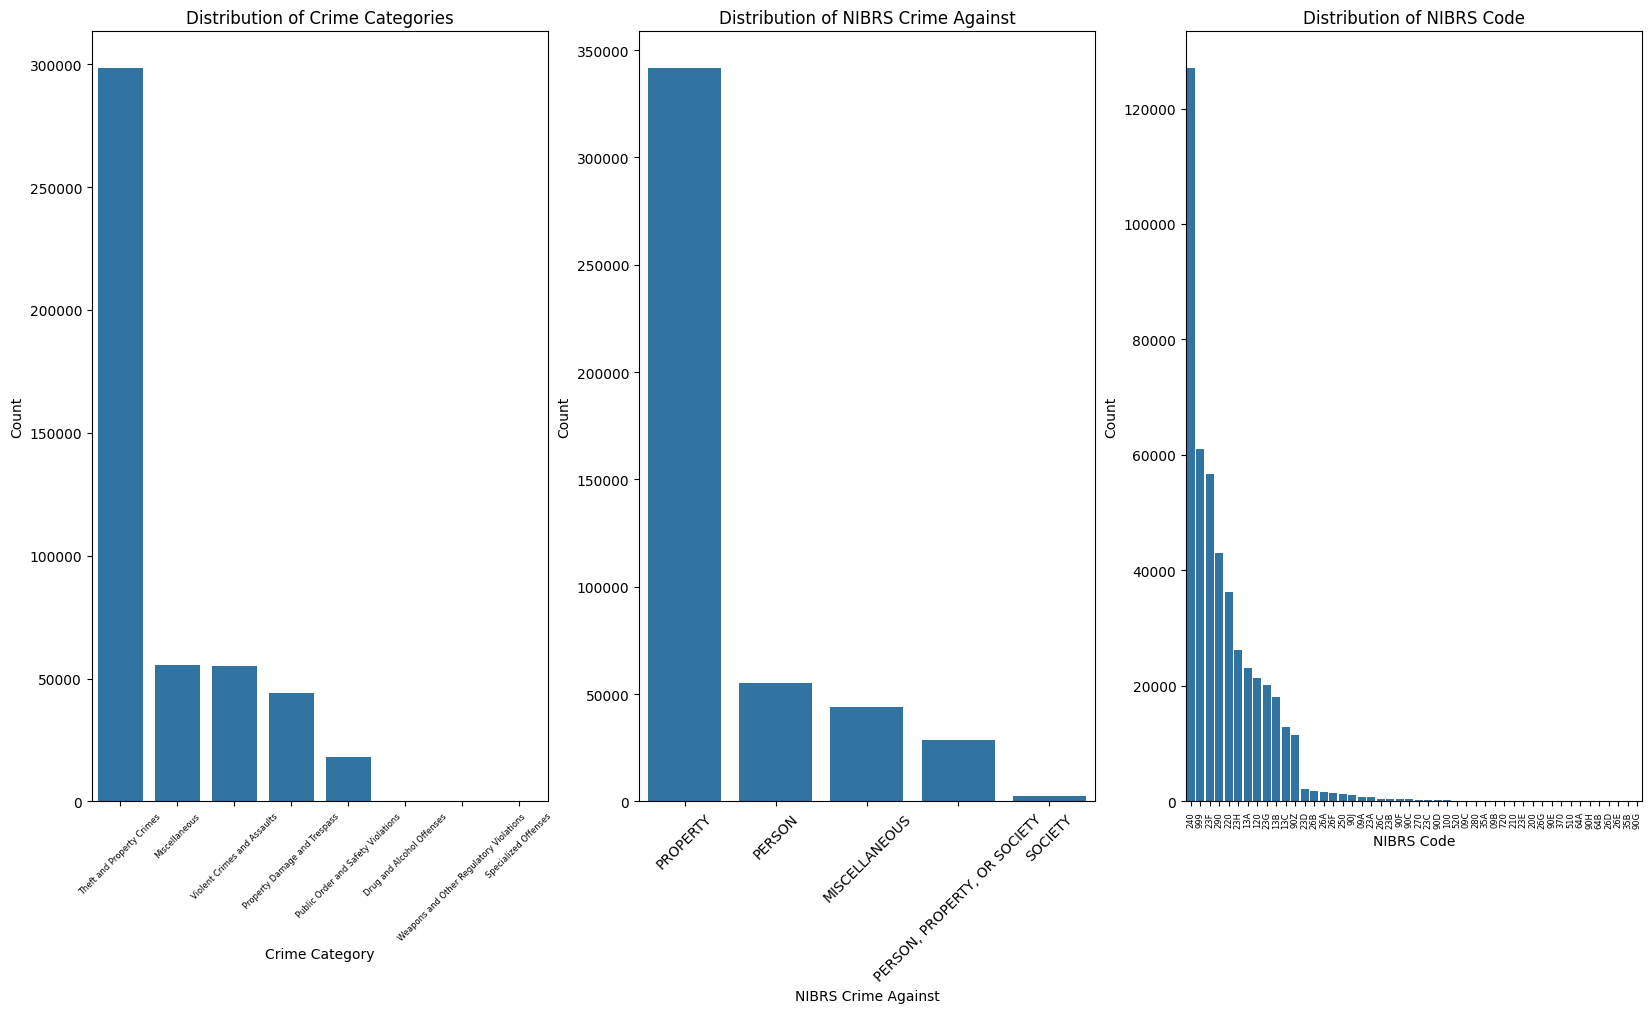

In [ ]:
#Plotting NIBRS attributes
plt.figure(figsize=(20, 10))

#NIBRS Crime Category
plt.subplot(1,3,1)
sns.countplot(x='NIBRS Crime Category', data=df_incident, order=df_incident['NIBRS Crime Category'].value_counts().index)
plt.title('Distribution of Crime Categories')
plt.xlabel('Crime Category')
plt.xticks(rotation=45,fontsize=6
           )
plt.ylabel('Count')

#NIBRS crime Against
plt.subplot(1,3,2)
sns.countplot(x='NIBRS Crime Against', data=df_incident, order=df_incident['NIBRS Crime Against'].value_counts().index)
plt.title("Distribution of NIBRS Crime Against")
plt.xlabel("NIBRS Crime Against")
plt.xticks(rotation=45)
plt.ylabel("Count")

#NIBRS code
plt.subplot(1,3,3)
sns.countplot(x='NIBRS Code', data=df_incident, order=df_incident['NIBRS Code'].value_counts().index)
plt.title("Distribution of NIBRS Code")
plt.xlabel("NIBRS Code")
plt.xticks(rotation=90, fontsize=6)
plt.ylabel("Count")




plt.show()

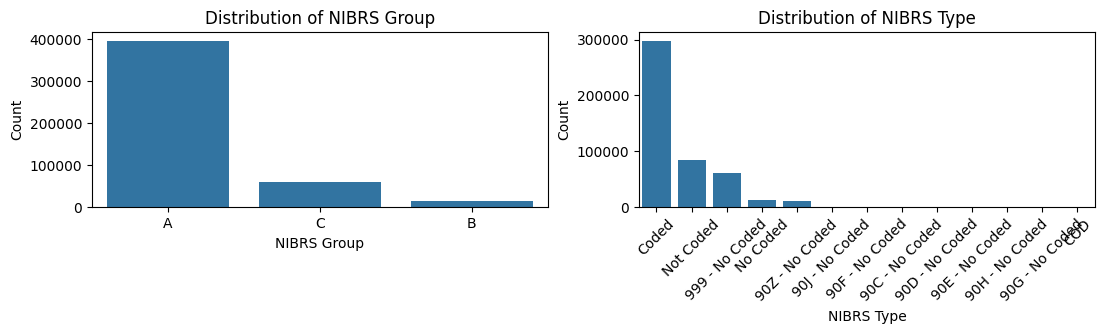

In [ ]:
#Plotting NIBRS attributes
plt.figure(figsize=(20, 5))

#NIBRS group
plt.subplot(2,3,1)
sns.countplot(x='NIBRS Group', data=df_incident, order=df_incident['NIBRS Group'].value_counts().index)
plt.title("Distribution of NIBRS Group")
plt.xlabel("NIBRS Group")
plt.ylabel("Count")

#NIBRS type
plt.subplot(2,3,2)
sns.countplot(x='NIBRS Type', data=df_incident, order=df_incident['NIBRS Type'].value_counts().index)
plt.title("Distribution of NIBRS Type")
plt.xlabel("NIBRS Type")
plt.xticks(rotation=45)
plt.ylabel("Count")

plt.show()

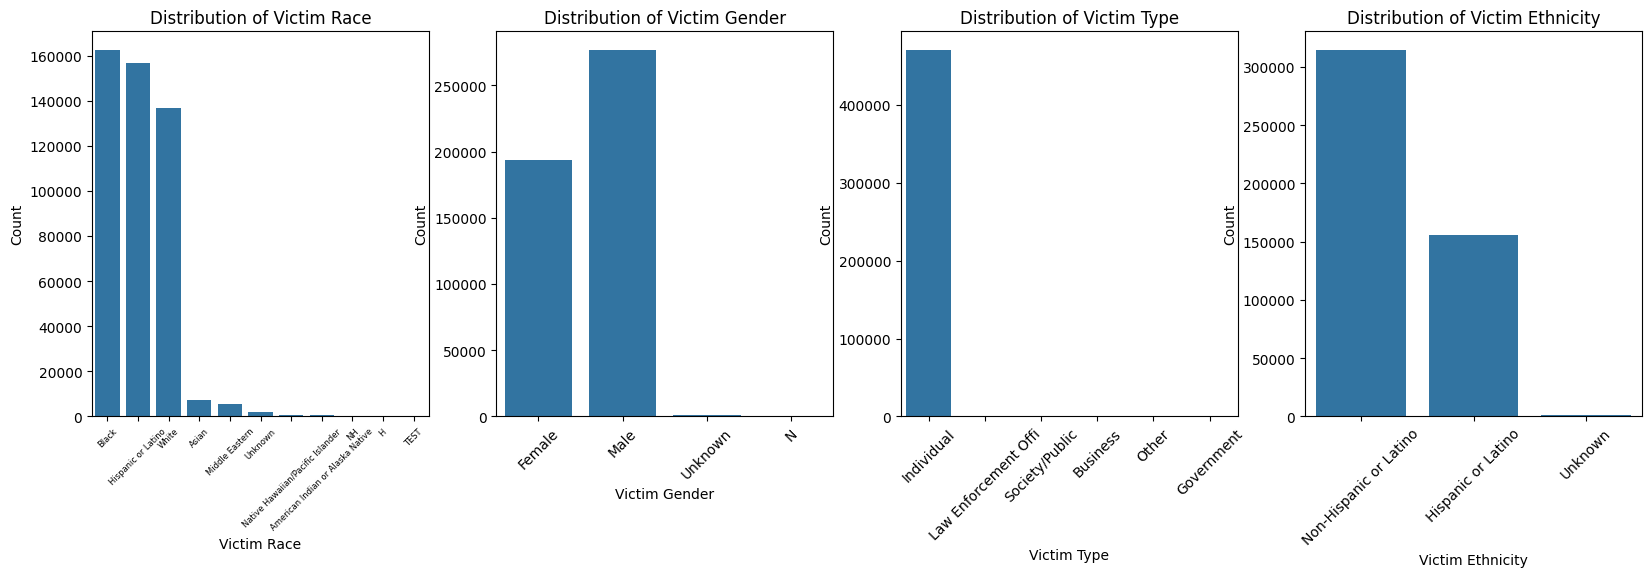

In [ ]:
#Plotting attributes based on victim
plt.figure(figsize=(20, 5))

#Victim race
plt.subplot(1, 4, 1)
sns.countplot(x='Victim Race', data=df_incident, order=df_incident['Victim Race'].value_counts().index)
plt.title('Distribution of Victim Race')
plt.xlabel('Victim Race')
plt.xticks(rotation=45, fontsize=6)
plt.ylabel('Count')

#Victim gender
plt.subplot(1, 4, 2)
sns.countplot(x='Victim Gender', data=df_incident)
plt.title('Distribution of Victim Gender')
plt.xlabel('Victim Gender')
plt.xticks(rotation=45)
plt.ylabel('Count')

#Victim type
plt.subplot(1, 4, 3)
sns.countplot(x='Victim Type', data=df_incident, order=df_incident['Victim Type'].value_counts().index)
plt.title('Distribution of Victim Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.xlabel('Victim Type')

#Victim ethnicity
plt.subplot(1, 4, 4)
sns.countplot(x='Victim Ethnicity', data=df_incident, order=df_incident['Victim Ethnicity'].value_counts().index)
plt.title("Distribution of Victim Ethnicity")
plt.xlabel("Victim Ethnicity")
plt.xticks(rotation=45)
plt.ylabel("Count")

plt.show()

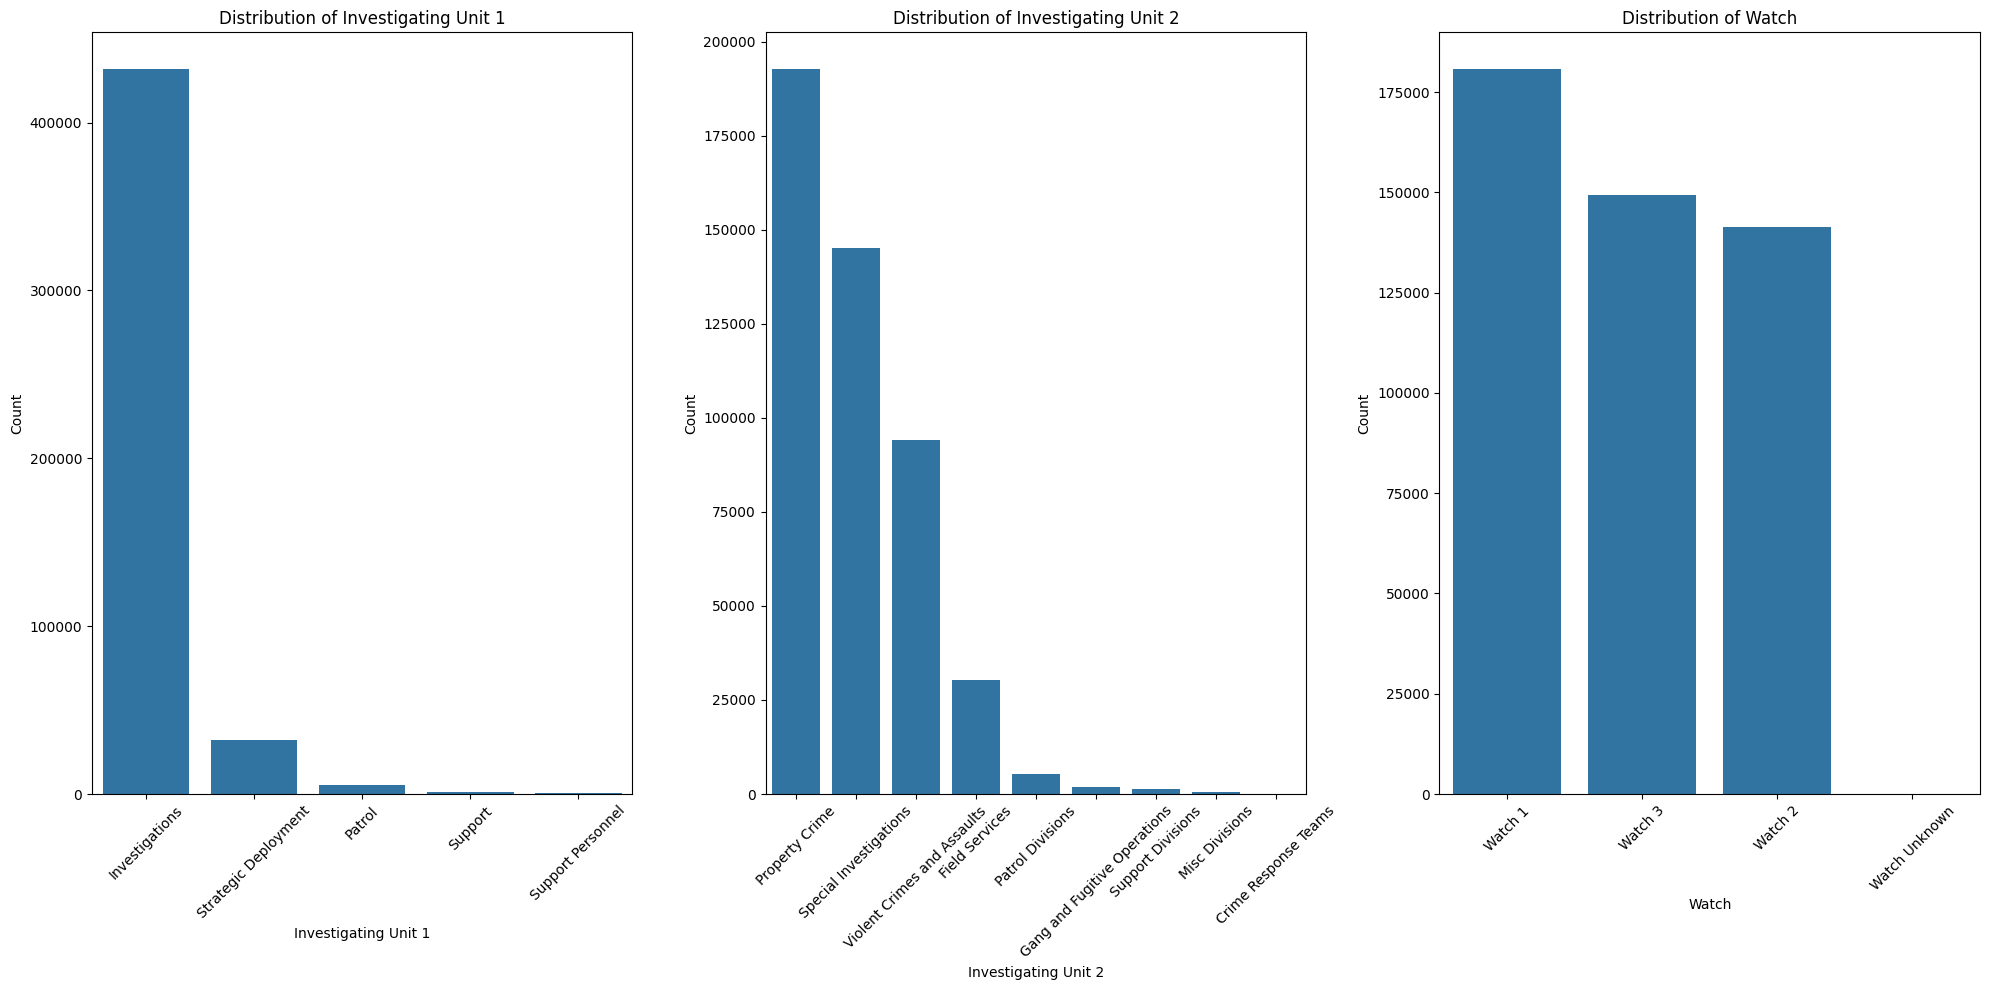

In [ ]:
#plotting different invertigating units and their watch time
plt.figure(figsize=(20, 10))

#Investigating Unit 1
plt.subplot(1,3,1)
sns.countplot(x='Investigating Unit 1', data=df_incident, order=df_incident['Investigating Unit 1'].value_counts().index)
plt.title("Distribution of Investigating Unit 1")
plt.xlabel("Investigating Unit 1")
plt.xticks(rotation=45)
plt.ylabel("Count")


#Investigating Unit 2
plt.subplot(1,3,2)
sns.countplot(x='Investigating Unit 2', data=df_incident, order=df_incident['Investigating Unit 2'].value_counts().index)
plt.title("Distribution of Investigating Unit 2")
plt.xlabel("Investigating Unit 2")
plt.xticks(rotation=45)
plt.ylabel("Count")

#Watch
plt.subplot(1,3,3)
sns.countplot(x='Watch', data=df_incident, order=df_incident['Watch'].value_counts().index)
plt.title('Distribution of Watch')
plt.xlabel('Watch')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.tight_layout()

plt.show()


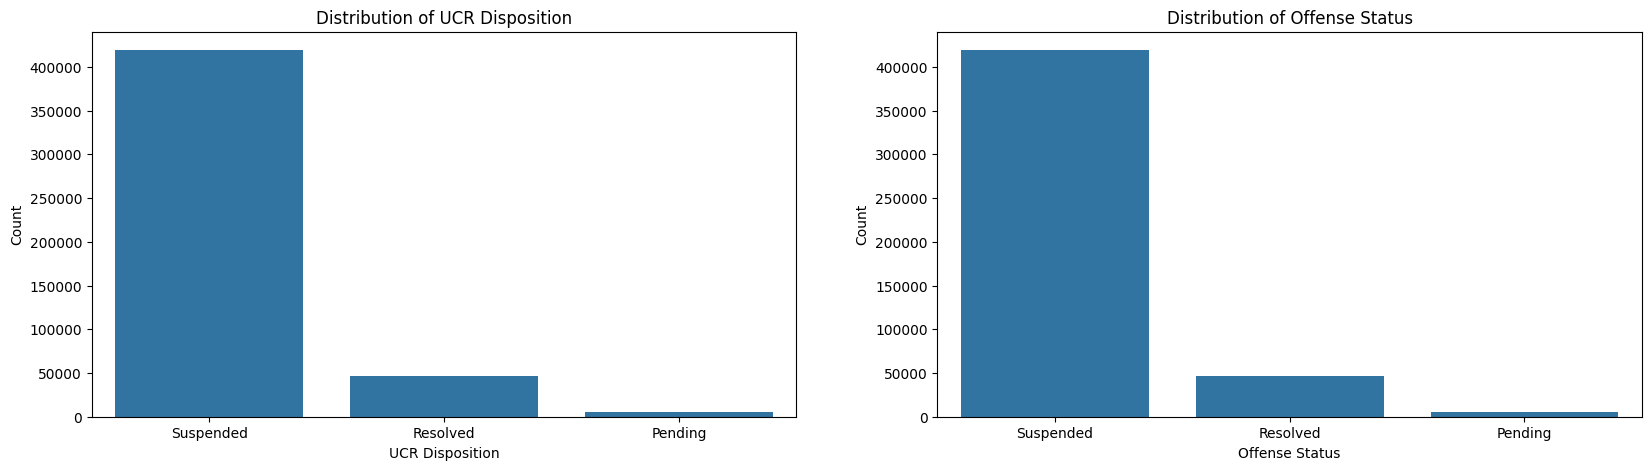

In [ ]:
#Plotting for Status for incident occurred
plt.figure(figsize=(20, 5))

#Plotting for UCR disposition
plt.subplot(1,2,1)
sns.countplot(x='UCR Disposition', data=df_incident, order=df_incident['UCR Disposition'].value_counts().index)
plt.title("Distribution of UCR Disposition")
plt.xlabel("UCR Disposition")
plt.ylabel("Count")

#Plotting for Offense Status
plt.subplot(1,2,2)
sns.countplot(x='Offense Status', data=df_incident, order=df_incident['Offense Status'].value_counts().index)
plt.title("Distribution of Offense Status")
plt.xlabel("Offense Status")
plt.ylabel("Count")

plt.show()


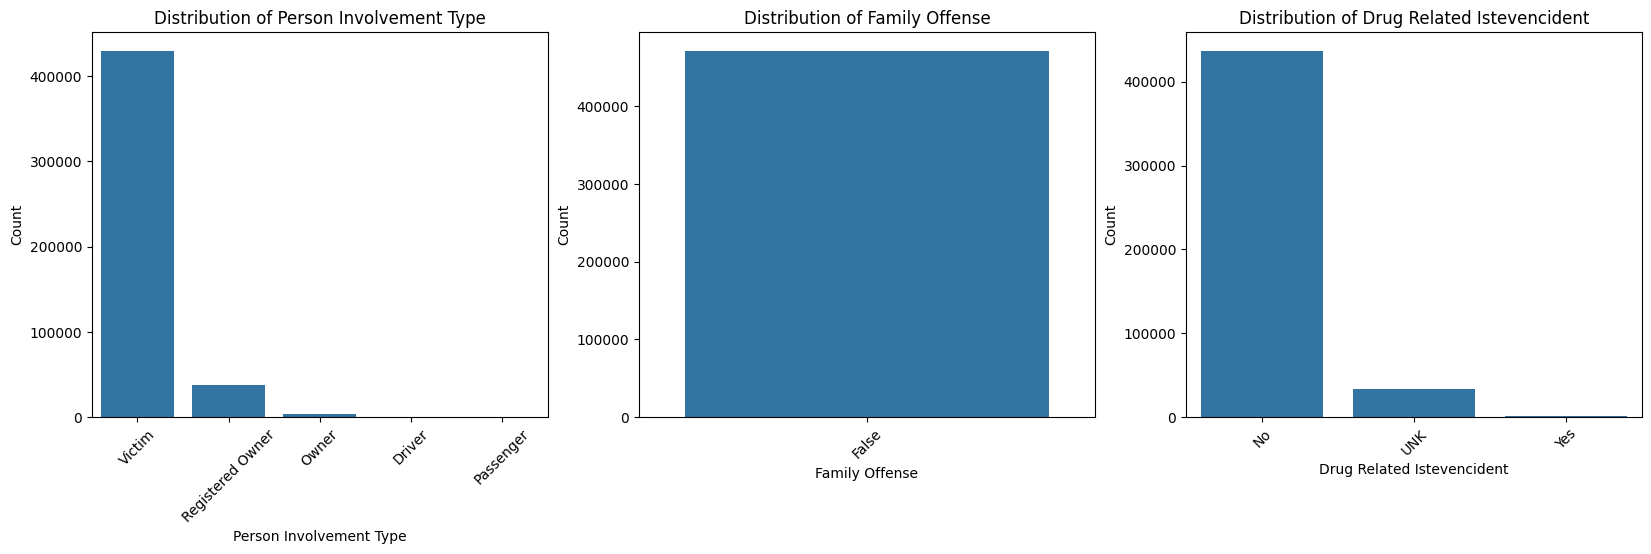

In [ ]:
#Plotting
plt.figure(figsize=(20, 5))

#potting Person Involvement Type
plt.subplot(1,3,1)
sns.countplot(x='Person Involvement Type', data=df_incident, order=df_incident['Person Involvement Type'].value_counts().index)
plt.title('Distribution of Person Involvement Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.xlabel('Person Involvement Type')

#plotting Family Offense
plt.subplot(1,3,2)
sns.countplot(x='Family Offense', data=df_incident, order=df_incident['Family Offense'].value_counts().index)
plt.title("Distribution of Family Offense")
plt.xlabel("Family Offense")
plt.xticks(rotation=45)
plt.ylabel("Count")


#plotting Drug Related Istevenciden
plt.subplot(1,3,3)
sns.countplot(x='Drug Related Istevencident', data=df_incident, order=df_incident['Drug Related Istevencident'].value_counts().index)
plt.title("Distribution of Drug Related Istevencident")
plt.xlabel("Drug Related Istevencident")
plt.xticks(rotation=45)
plt.ylabel("Count")

plt.show()

After visualization we can tell right away that the data in family offense and Victim Type are only in one of categories, So they don't have any valuable information and can be deleted from the dataset

In [ ]:
#deleting victim type and family offense
df_incident.drop(['Victim Type', 'Family Offense'], axis=1, inplace=True)

In [ ]:
#saving the dataset for further preprocessing
save_path = '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_cleaned_with_outliers.csv'
df_incident.to_csv(save_path, index=False)  # Set index=False to avoid saving the index column

##Checking relation between UCR Disposition and Offense Status

In [ ]:
#Loading the Dataset
save_path = '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_cleaned_with_outliers.csv'
df_incident = pd.read_csv(save_path, index_col= None)

In [ ]:
ucr_offense_rel = pd.crosstab(df_incident['UCR Disposition'], df_incident['Offense Status'])
ucr_offense_rel

Offense Status,Pending,Resolved,Suspended
UCR Disposition,,,
Pending,5334,10,55
Resolved,11,46934,60
Suspended,80,46,419113


In [ ]:
ucr_offense_euq = df_incident['UCR Disposition'] == df_incident['Offense Status']

In [ ]:
ucr_offense_euq.value_counts()

,count
True,471381
False,262


In [ ]:
df_incident.drop(['UCR Disposition'], axis=1, inplace=True)

#Save dataset
save_path = '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_cleaned_with_outliers.csv'
df_incident.to_csv(save_path, index=False)  # Set index=False to avoid saving the index column

##Eliminating Outliers

In [ ]:
#calculating sum of categories in all of the categorical attributes
sum_of_all_categories = 0
for col in df_incident.columns:
    if (col != 'Call Cleared Date Time') & (col != 'Call Dispatch Date Time'):
        sum_of_all_categories += df_incident[col].nunique()
print(f"sum of all categories: {sum_of_all_categories}")

sum of all categories: 179


In [ ]:
#calculating the categories with less than 1% of data
#calculating number of instances
total_count = len(df_incident)
indices_to_drop=[]
for col in df_incident.columns:
    #ignoring Call Cleared Date Time and Call Dispatch Date Time as they are not categorical
    if (col != 'Call Cleared Date Time') & (col != 'Call Dispatch Date Time'):
        for cat in df_incident[col].unique():
            num_of_category_value = df_incident[col].value_counts()[cat]
            if num_of_category_value / total_count < 0.001:
                print(f"Column: '{col}' , Category: '{cat} , Number of Items: {num_of_category_value}' ")
                #creating a list of indices to drop these categories
                indices_to_drop.append(df_incident[df_incident[col].isin([cat])].index)


Column: 'Watch' , Category: 'Watch Unknown , Number of Items: 1' 
Column: 'Council District' , Category: '10 , Number of Items: 2' 
Column: 'Council District' , Category: '11 , Number of Items: 1' 
Column: 'Council District' , Category: '8 , Number of Items: 1' 
Column: 'Person Involvement Type' , Category: 'Driver , Number of Items: 169' 
Column: 'Person Involvement Type' , Category: 'Passenger , Number of Items: 12' 
Column: 'Victim Race' , Category: 'NH , Number of Items: 127' 
Column: 'Victim Race' , Category: 'H , Number of Items: 13' 
Column: 'Victim Race' , Category: 'TEST , Number of Items: 1' 
Column: 'Victim Gender' , Category: 'N , Number of Items: 1' 
Column: 'Investigating Unit 1' , Category: 'Support Personnel , Number of Items: 422' 
Column: 'Investigating Unit 2' , Category: 'Crime Response Teams , Number of Items: 29' 
Column: 'NIBRS Crime Category' , Category: 'Specialized Offenses , Number of Items: 37' 
Column: 'NIBRS Crime Category' , Category: 'Drug and Alcohol Of

In [ ]:
#eliminating instances with the categories with less than 0.1% data in them as they are outliers
# Flatten the list of indices to drop
indices_to_drop = [item for sublist in indices_to_drop for item in sublist]
df_incident = df_incident.drop(indices_to_drop)

In [ ]:
df_incident.shape

(467938, 19)

In [ ]:
#calculating sum of categories in all of the categorical attributes after deleting low-frequency categories
sum_of_all_categories = 0
for col in df_incident.columns:
    if (col != 'Call Cleared Date Time') & (col != 'Call Dispatch Date Time'):
        sum_of_all_categories += df_incident[col].nunique()
print(f"sum of all categories: {sum_of_all_categories}")

sum of all categories: 130


In [ ]:
#saving the dataset for further preprocessing
save_path = '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_cleaned_without_outliers.csv'
df_incident.to_csv(save_path, index=False)  # Set index=False to avoid saving the index column

##DO NOT READ - Chi-squre test

Source:
https://medium.com/@ritesh.110587/correlation-between-categorical-variables-63f6bd9bf2f7

In [ ]:
#importing dataset
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_cleaned_without_outliers.csv'

df_incident = pd.read_csv(directory, index_col= None)

In [ ]:
#creating a list of categorical columns
cat_var = [col for col in df_incident.columns if (col != 'Call Cleared Date Time') & (col != 'Call Dispatch Date Time')]
len(cat_var)

17

In [ ]:
#Creating all possible combinations of the categorical attributes
cat_var_prod = list(product(cat_var,cat_var, repeat = 1))
print(cat_var_prod)
print(len(cat_var_prod))

[('Watch', 'Watch'), ('Watch', 'Division'), ('Watch', 'Sector'), ('Watch', 'Council District'), ('Watch', 'Person Involvement Type'), ('Watch', 'Victim Race'), ('Watch', 'Victim Ethnicity'), ('Watch', 'Victim Gender'), ('Watch', 'Investigating Unit 1'), ('Watch', 'Investigating Unit 2'), ('Watch', 'Offense Status'), ('Watch', 'Drug Related Istevencident'), ('Watch', 'NIBRS Crime Category'), ('Watch', 'NIBRS Crime Against'), ('Watch', 'NIBRS Code'), ('Watch', 'NIBRS Group'), ('Watch', 'NIBRS Type'), ('Division', 'Watch'), ('Division', 'Division'), ('Division', 'Sector'), ('Division', 'Council District'), ('Division', 'Person Involvement Type'), ('Division', 'Victim Race'), ('Division', 'Victim Ethnicity'), ('Division', 'Victim Gender'), ('Division', 'Investigating Unit 1'), ('Division', 'Investigating Unit 2'), ('Division', 'Offense Status'), ('Division', 'Drug Related Istevencident'), ('Division', 'NIBRS Crime Category'), ('Division', 'NIBRS Crime Against'), ('Division', 'NIBRS Code'),

In [ ]:
# Remove duplicates by treating (col1, col2) and (col2, col1) as equivalent
cat_var_prod_no_duplicates = [tuple(sorted(tup)) for tup in cat_var_prod]
cat_var_prod_no_duplicates = list(set(cat_var_prod_no_duplicates))
print(cat_var_prod_no_duplicates)
print(len(cat_var_prod_no_duplicates))

[('NIBRS Type', 'Sector'), ('Division', 'Person Involvement Type'), ('NIBRS Crime Category', 'Watch'), ('Drug Related Istevencident', 'Victim Race'), ('NIBRS Code', 'Victim Gender'), ('Investigating Unit 2', 'Watch'), ('Drug Related Istevencident', 'NIBRS Type'), ('Council District', 'Investigating Unit 2'), ('NIBRS Code', 'Victim Ethnicity'), ('NIBRS Type', 'Person Involvement Type'), ('Investigating Unit 1', 'Investigating Unit 1'), ('Council District', 'Sector'), ('NIBRS Crime Against', 'NIBRS Group'), ('Offense Status', 'Person Involvement Type'), ('NIBRS Code', 'NIBRS Code'), ('NIBRS Crime Category', 'Offense Status'), ('Council District', 'Division'), ('Investigating Unit 1', 'Victim Gender'), ('Investigating Unit 2', 'Investigating Unit 2'), ('Investigating Unit 2', 'Offense Status'), ('NIBRS Crime Category', 'Sector'), ('Council District', 'Victim Race'), ('Investigating Unit 1', 'Victim Ethnicity'), ('Council District', 'NIBRS Type'), ('Victim Gender', 'Watch'), ('Drug Related

In [ ]:
## Creating an empty variable and picking only the p value from the output of Chi-Square test
result = []
for i in cat_var_prod_no_duplicates:
    if i[0] != i[1]:
        result.append((i[0],i[1],list(ss.chi2_contingency(pd.crosstab(
                            df_incident[i[0]], df_incident[i[1]])))[1]))

In [ ]:
result

[('NIBRS Type', 'Sector', 0.0),
 ('Division', 'Person Involvement Type', 2.049572158601504e-156),
 ('NIBRS Crime Category', 'Watch', 0.0),
 ('Drug Related Istevencident', 'Victim Race', 7.390629997093171e-30),
 ('NIBRS Code', 'Victim Gender', 0.0),
 ('Investigating Unit 2', 'Watch', 0.0),
 ('Drug Related Istevencident', 'NIBRS Type', 1.2674917153454344e-283),
 ('Council District', 'Investigating Unit 2', 0.0),
 ('NIBRS Code', 'Victim Ethnicity', 0.0),
 ('NIBRS Type', 'Person Involvement Type', 0.0),
 ('Council District', 'Sector', 0.0),
 ('NIBRS Crime Against', 'NIBRS Group', 0.0),
 ('Offense Status', 'Person Involvement Type', 1.5885856853583175e-182),
 ('NIBRS Crime Category', 'Offense Status', 0.0),
 ('Council District', 'Division', 0.0),
 ('Investigating Unit 1', 'Victim Gender', 0.0),
 ('Investigating Unit 2', 'Offense Status', 0.0),
 ('NIBRS Crime Category', 'Sector', 0.0),
 ('Council District', 'Victim Race', 0.0),
 ('Investigating Unit 1', 'Victim Ethnicity', 0.0),
 ('Council D

In [ ]:
chi_test_output = pd.DataFrame(result, columns = ['var1', 'var2', 'coeff'])
## Using pivot function to convert the above DataFrame into a crosstab
chi_test_output.pivot(index='var1', columns='var2', values='coeff')

var2,Division,Drug Related Istevencident,Investigating Unit 1,Investigating Unit 2,NIBRS Code,NIBRS Crime Against,NIBRS Crime Category,NIBRS Group,NIBRS Type,Offense Status,Person Involvement Type,Sector,Victim Ethnicity,Victim Gender,Victim Race,Watch
var1,,,,,,,,,,,,,,,,
Council District,0.0,8.597341e-89,0.000000e+00,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,1.729241e-175,1.441669e-247,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.748482e-252
Division,NaN,2.746715e-49,0.000000e+00,0.0,0.0,0.0,0.0,4.006347e-281,0.000000e+00,6.173135e-109,2.049572e-156,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.410679e-63
Drug Related Istevencident,NaN,NaN,3.827020e-17,0.0,0.0,0.0,0.0,1.090376e-136,1.267492e-283,0.000000e+00,5.122508e-52,1.112619e-128,1.284728e-24,1.270336e-40,7.390630e-30,1.754526e-08
Investigating Unit 1,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.522319e-171
Investigating Unit 2,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
NIBRS Code,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
NIBRS Crime Against,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
NIBRS Crime Category,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
NIBRS Group,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.949093e-268,0.000000e+00,4.259071e-277


##Checking the disturbution of the class before and after cleaning

In [ ]:
#loading the original dataset
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/Police_Incidents_20241030.csv'

df_incident_original = pd.read_csv(directory, index_col= None)

#loading the preprocessed dataset
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_cleaned_without_outliers.csv'

df_incident_processed = pd.read_csv(directory, index_col= None)

<ipython-input-70-c07599ba95c8>:4: DtypeWarning: Columns (3,53,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df_incident_original = pd.read_csv(directory, index_col= None)


In [ ]:
#mapping the class attribute in the original dataset
status_mapping = {
    'Suspended': 'Suspended',
    'Clear by Arrest': 'Resolved',
    'Clear by Exceptional Arrest': 'Resolved',
    'Open': 'Pending',
    'Closed/Cleared': 'Resolved',
    'nan': 'Nan',
    'Returned for Correction': 'Pending',
    'L': 'Suspended'
}

# Appling the mapping
df_incident_original['Offense Status'] = df_incident_original['Offense Status'].map(status_mapping)


In [ ]:
#Checking the disturbution of the class attribute
original_dist = df_incident_original['Offense Status'].value_counts(normalize=  True) * 100
processed_dist = df_incident_processed['Offense Status'].value_counts(normalize=  True) * 100

print("Original Distribution:")
print(original_dist)

print("\nProcessed Distribution:")
print(processed_dist)

Original Distribution:
Offense Status
Suspended    82.700404
Resolved     14.825820
Pending       2.473775
Name: proportion, dtype: float64

Processed Distribution:
Offense Status
Suspended    89.067141
Resolved      9.785271
Pending       1.147588
Name: proportion, dtype: float64


##Further Visualization

In [ ]:
#Upload the data frame
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_cleaned_without_outliers.csv'

df_incident = pd.read_csv(directory, index_col= None)

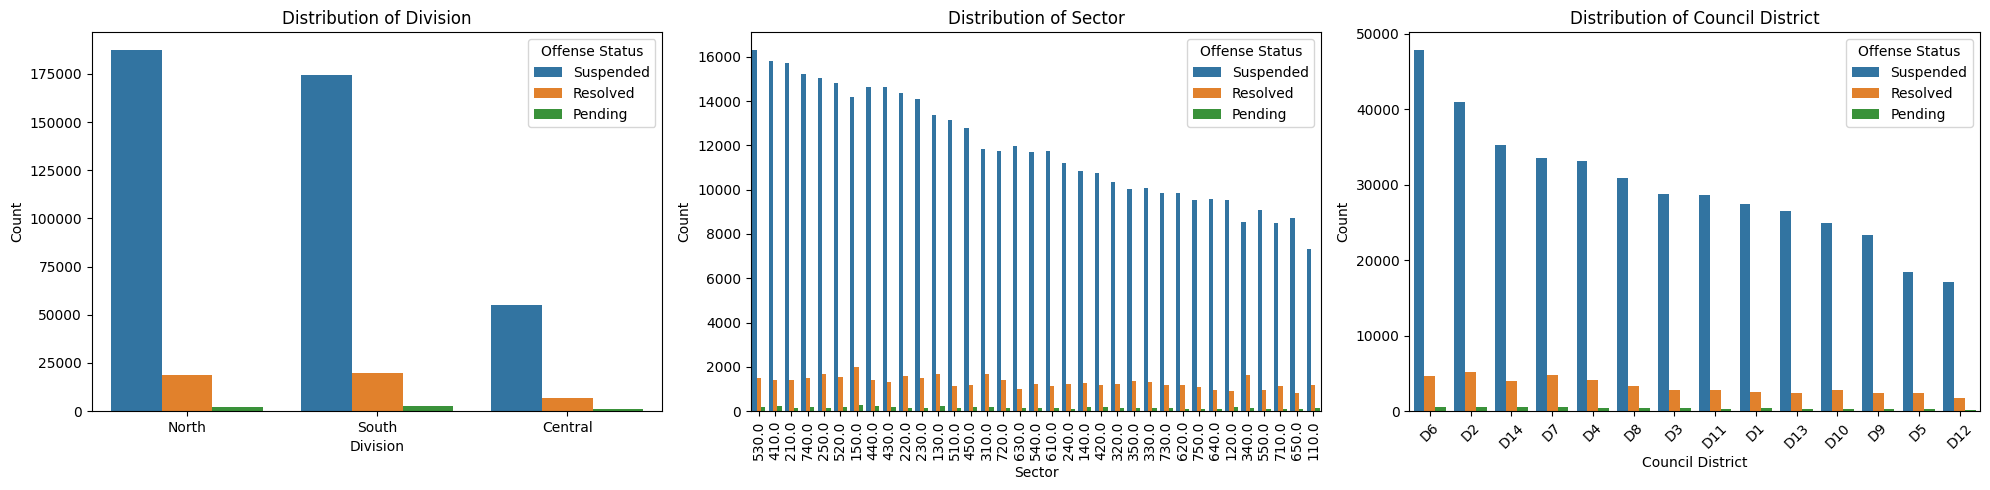

In [ ]:
#Plotting attributes with the location data (Division, Sector, Council district)
#We used subplot to plot all of them in a row
plt.figure(figsize=(20, 5))

#Plotting Division
plt.subplot(1, 3, 1)
sns.countplot(x='Division',hue='Offense Status', data=df_incident, order=df_incident['Division'].value_counts().index)
plt.title("Distribution of Division")
plt.xlabel("Division")
plt.ylabel("Count")
plt.legend(title='Offense Status', loc='upper right')

#Plotting Sector
plt.subplot(1, 3, 2)
sns.countplot(x='Sector',hue='Offense Status', data=df_incident, order=df_incident['Sector'].value_counts().index)
plt.title("Distribution of Sector")
plt.xlabel("Sector")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.tight_layout()
plt.legend(title='Offense Status', loc='upper right')

#Plotting Council District
plt.subplot(1, 3, 3)
sns.countplot(x='Council District',hue='Offense Status', data=df_incident, order=df_incident['Council District'].value_counts().index)
plt.title("Distribution of Council District")
plt.xlabel("Council District")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.legend(title='Offense Status', loc='upper right')

plt.show()

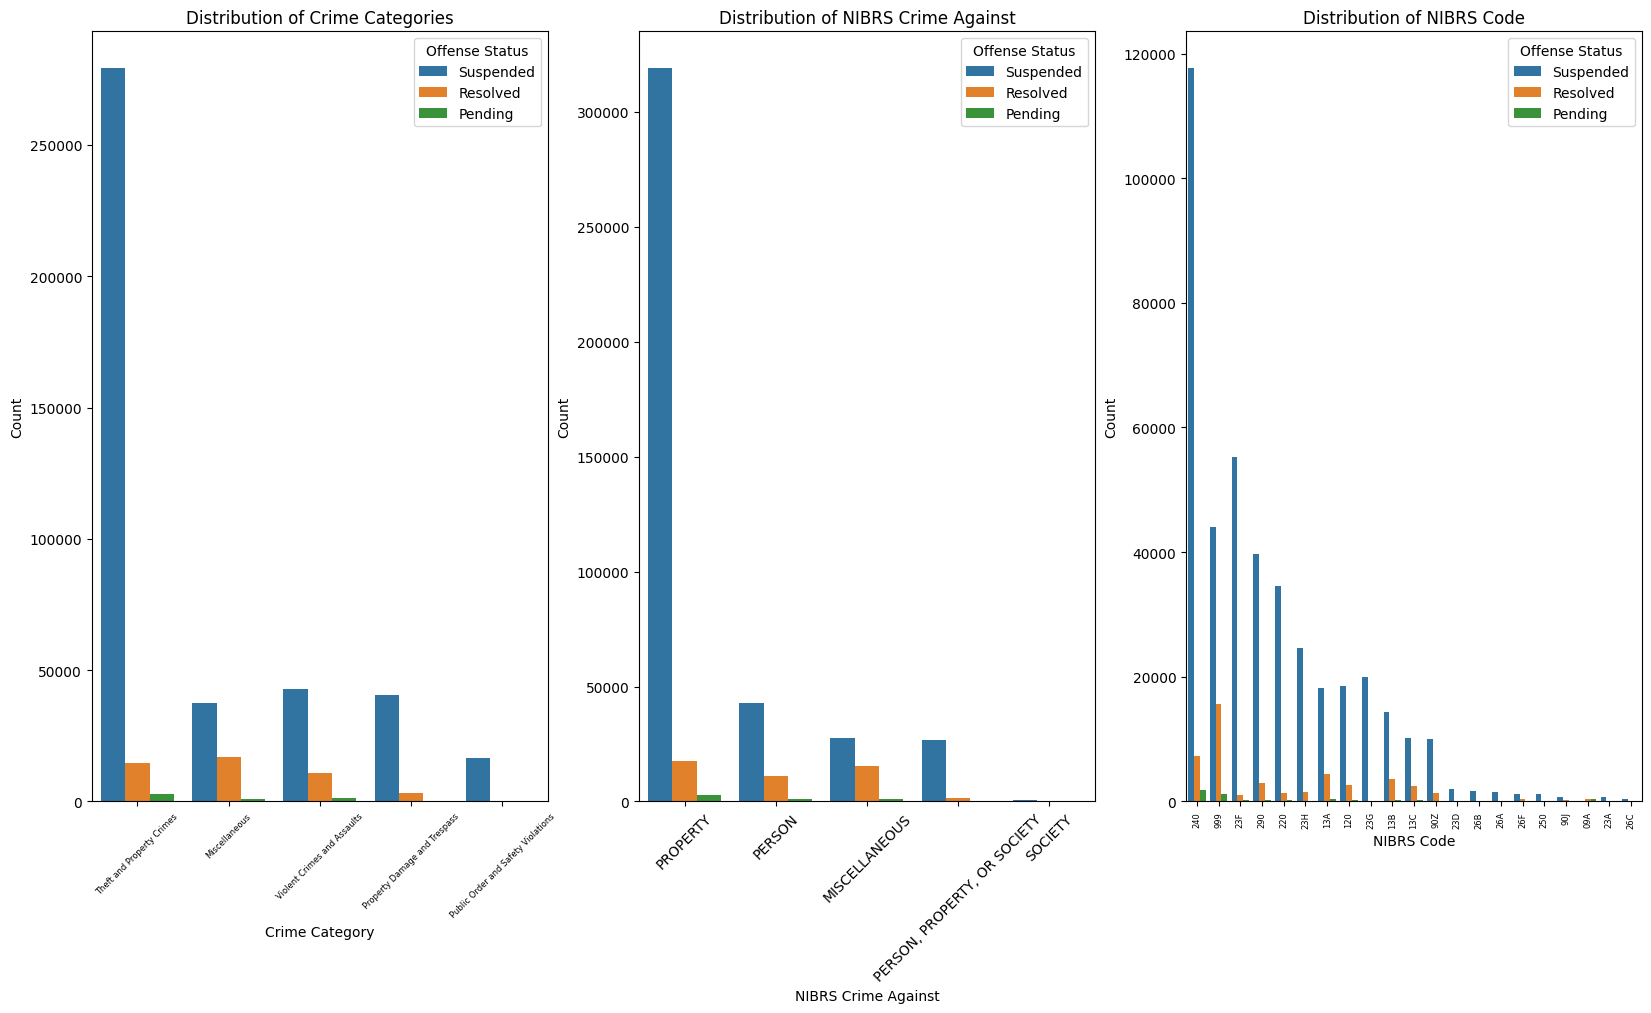

In [ ]:
#Plotting NIBRS attributes
plt.figure(figsize=(20, 10))

#NIBRS Crime Category
plt.subplot(1,3,1)
sns.countplot(x='NIBRS Crime Category',hue='Offense Status', data=df_incident, order=df_incident['NIBRS Crime Category'].value_counts().index)
plt.title('Distribution of Crime Categories')
plt.xlabel('Crime Category')
plt.xticks(rotation=45,fontsize=6)
plt.ylabel('Count')
plt.legend(title='Offense Status', loc='upper right')

#NIBRS crime Against
plt.subplot(1,3,2)
sns.countplot(x='NIBRS Crime Against',hue='Offense Status', data=df_incident, order=df_incident['NIBRS Crime Against'].value_counts().index)
plt.title("Distribution of NIBRS Crime Against")
plt.xlabel("NIBRS Crime Against")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.legend(title='Offense Status', loc='upper right')

#NIBRS code
plt.subplot(1,3,3)
sns.countplot(x='NIBRS Code',hue='Offense Status', data=df_incident, order=df_incident['NIBRS Code'].value_counts().index)
plt.title("Distribution of NIBRS Code")
plt.xlabel("NIBRS Code")
plt.xticks(rotation=90, fontsize=6)
plt.ylabel("Count")
plt.legend(title='Offense Status', loc='upper right')




plt.show()

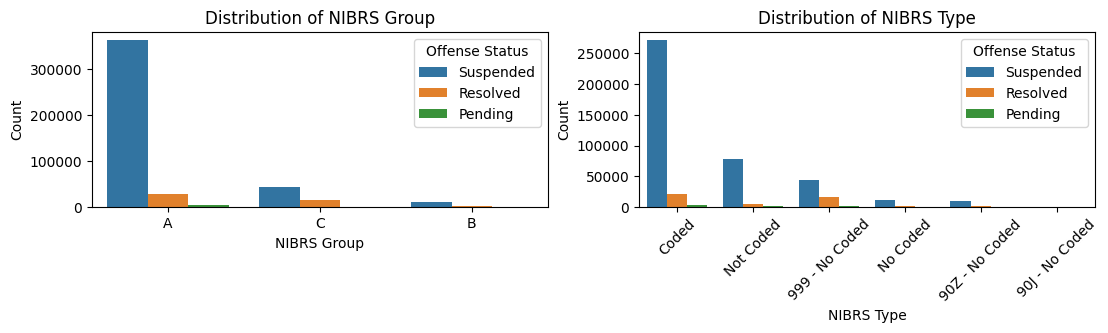

In [ ]:
#Plotting NIBRS attributes
plt.figure(figsize=(20, 5))

#NIBRS group
plt.subplot(2,3,1)
sns.countplot(x='NIBRS Group',hue='Offense Status', data=df_incident, order=df_incident['NIBRS Group'].value_counts().index)
plt.title("Distribution of NIBRS Group")
plt.xlabel("NIBRS Group")
plt.ylabel("Count")
plt.legend(title='Offense Status', loc='upper right')


#NIBRS type
plt.subplot(2,3,2)
sns.countplot(x='NIBRS Type',hue='Offense Status', data=df_incident, order=df_incident['NIBRS Type'].value_counts().index)
plt.title("Distribution of NIBRS Type")
plt.xlabel("NIBRS Type")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.legend(title='Offense Status', loc='upper right')


plt.show()

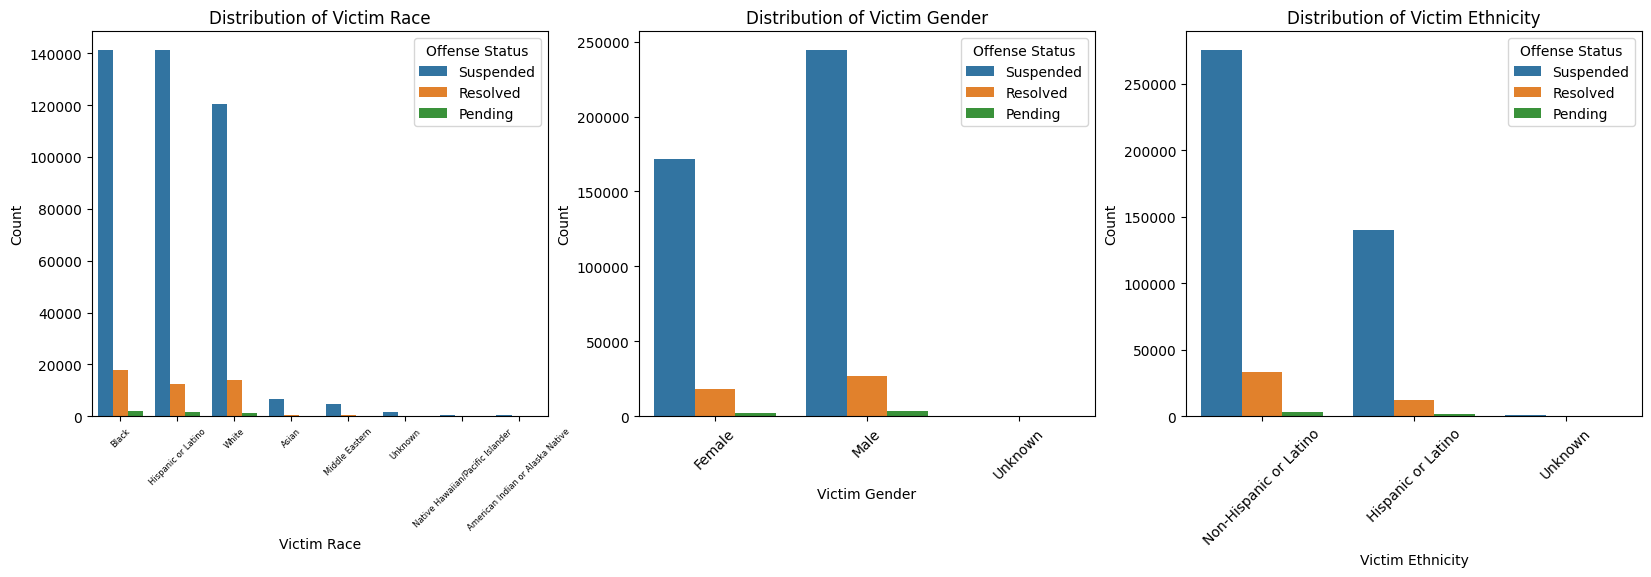

In [ ]:
#Plotting attributes based on victim
plt.figure(figsize=(20, 5))

#Victim race
plt.subplot(1, 3, 1)
sns.countplot(x='Victim Race',hue='Offense Status', data=df_incident, order=df_incident['Victim Race'].value_counts().index)
plt.title('Distribution of Victim Race')
plt.xlabel('Victim Race')
plt.xticks(rotation=45, fontsize=6)
plt.ylabel('Count')
plt.legend(title='Offense Status', loc='upper right')


#Victim gender
plt.subplot(1, 3, 2)
sns.countplot(x='Victim Gender',hue='Offense Status', data=df_incident)
plt.title('Distribution of Victim Gender')
plt.xlabel('Victim Gender')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.legend(title='Offense Status', loc='upper right')


#Victim ethnicity
plt.subplot(1, 3, 3)
sns.countplot(x='Victim Ethnicity',hue='Offense Status', data=df_incident, order=df_incident['Victim Ethnicity'].value_counts().index)
plt.title("Distribution of Victim Ethnicity")
plt.xlabel("Victim Ethnicity")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.legend(title='Offense Status', loc='upper right')

plt.show()

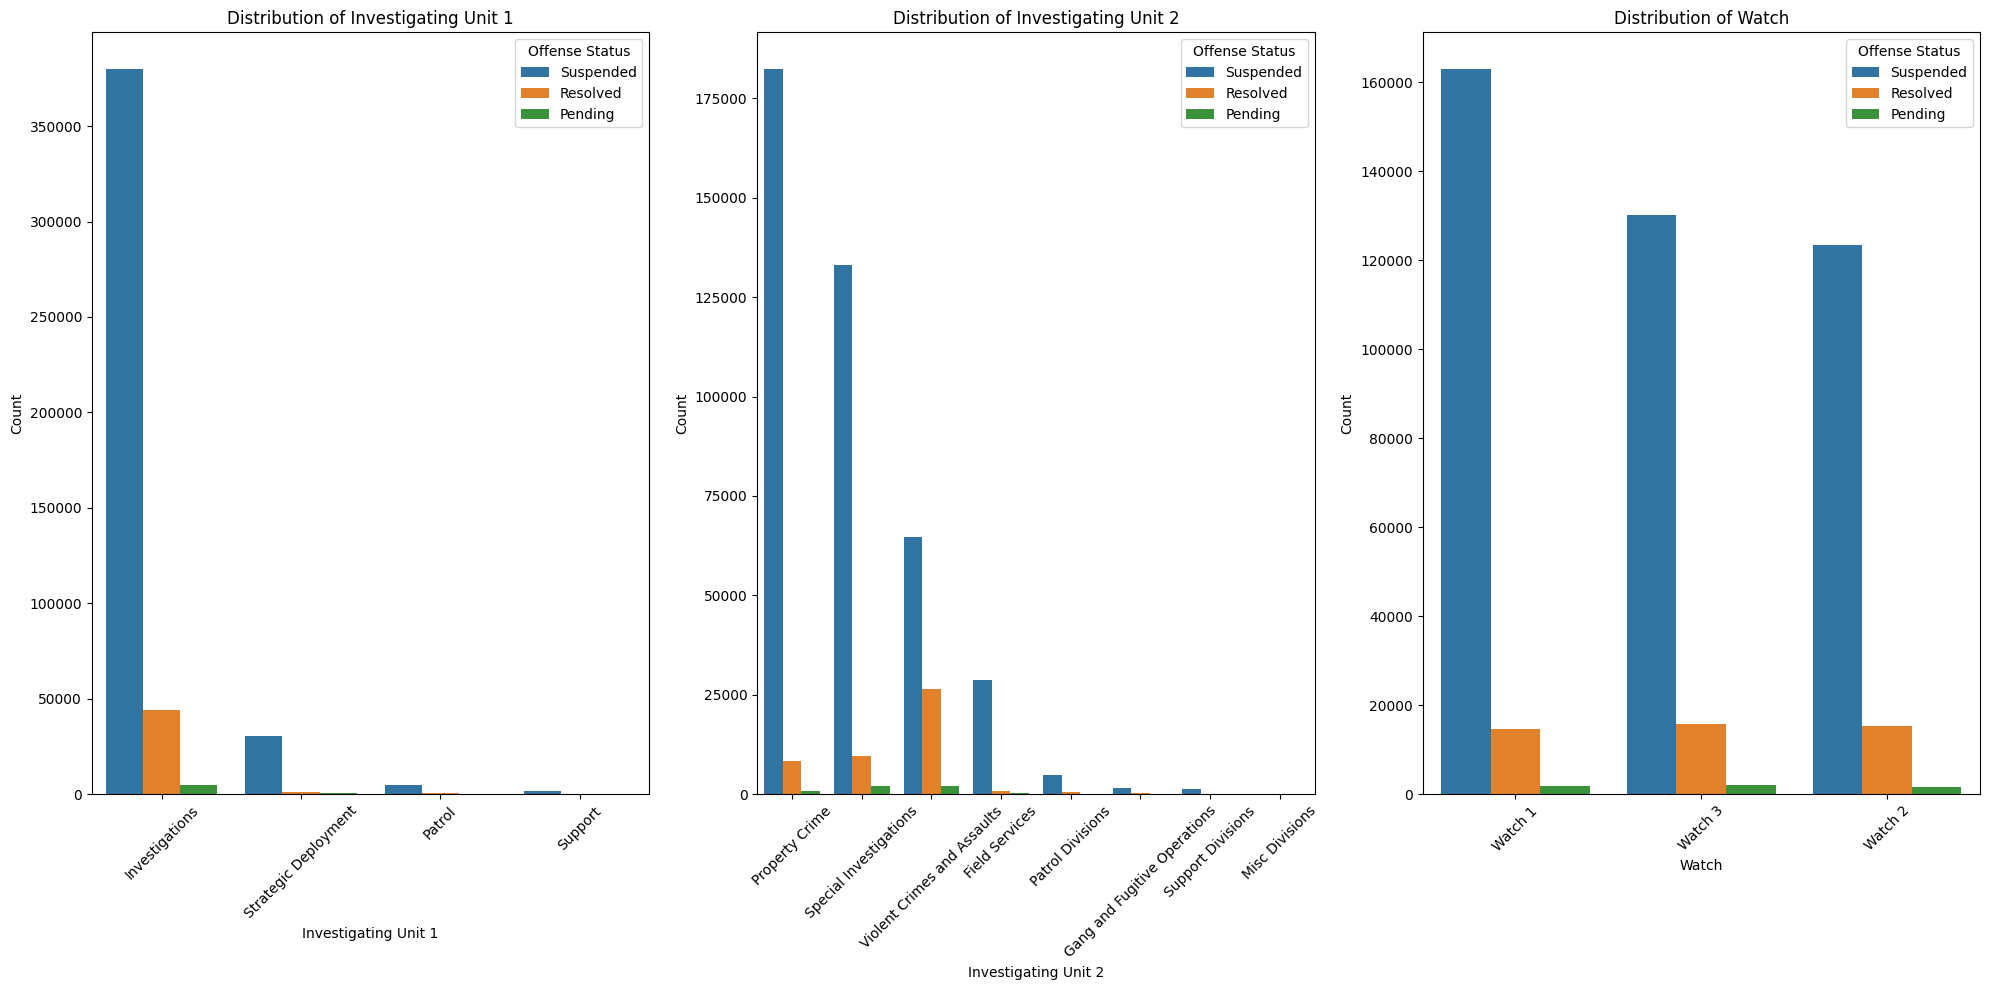

In [ ]:
#plotting different invertigating units and their watch time
plt.figure(figsize=(20, 10))

#Investigating Unit 1
plt.subplot(1,3,1)
sns.countplot(x='Investigating Unit 1',hue='Offense Status', data=df_incident, order=df_incident['Investigating Unit 1'].value_counts().index)
plt.title("Distribution of Investigating Unit 1")
plt.xlabel("Investigating Unit 1")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.legend(title='Offense Status', loc='upper right')


#Investigating Unit 2
plt.subplot(1,3,2)
sns.countplot(x='Investigating Unit 2',hue='Offense Status', data=df_incident, order=df_incident['Investigating Unit 2'].value_counts().index)
plt.title("Distribution of Investigating Unit 2")
plt.xlabel("Investigating Unit 2")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.legend(title='Offense Status', loc='upper right')

#Watch
plt.subplot(1,3,3)
sns.countplot(x='Watch',hue='Offense Status', data=df_incident, order=df_incident['Watch'].value_counts().index)
plt.title('Distribution of Watch')
plt.xlabel('Watch')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.tight_layout()
plt.legend(title='Offense Status', loc='upper right')

plt.show()


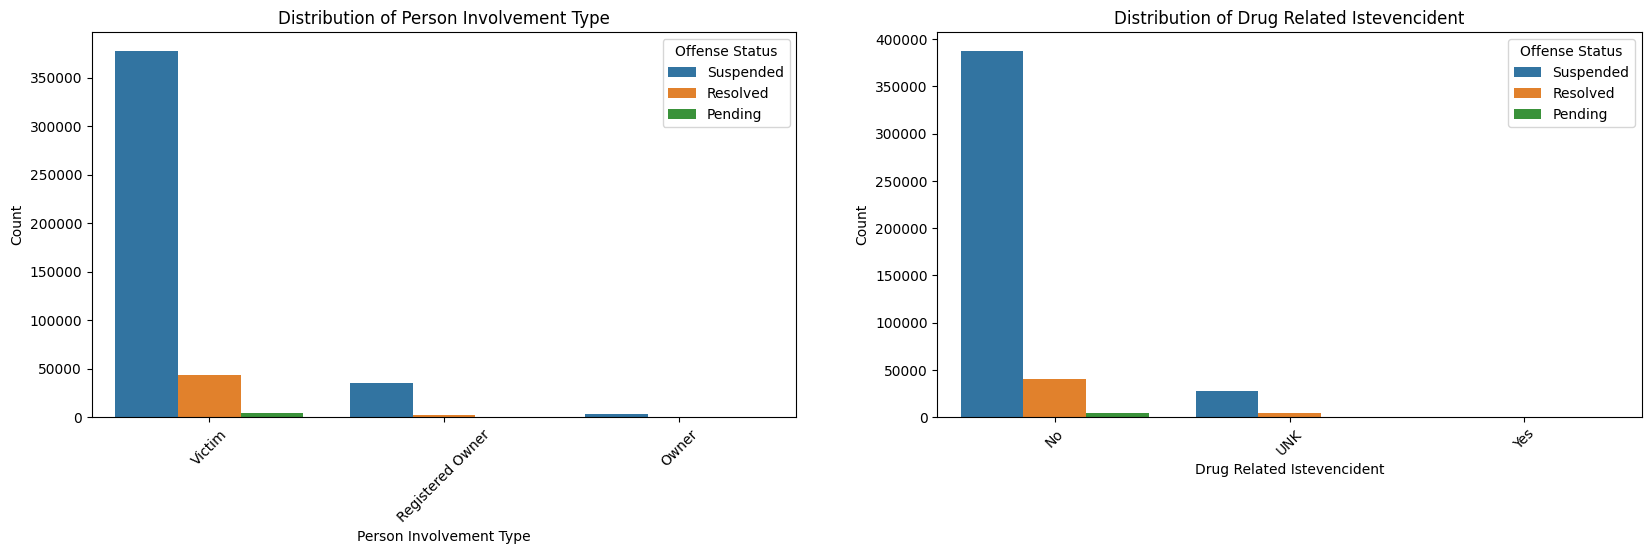

In [ ]:
#Plotting
plt.figure(figsize=(20, 5))

#potting Person Involvement Type
plt.subplot(1,2,1)
sns.countplot(x='Person Involvement Type',hue='Offense Status', data=df_incident, order=df_incident['Person Involvement Type'].value_counts().index)
plt.title('Distribution of Person Involvement Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.xlabel('Person Involvement Type')
plt.legend(title='Offense Status', loc='upper right')


#plotting Drug Related Istevenciden
plt.subplot(1,2,2)
sns.countplot(x='Drug Related Istevencident',hue='Offense Status', data=df_incident, order=df_incident['Drug Related Istevencident'].value_counts().index)
plt.title("Distribution of Drug Related Istevencident")
plt.xlabel("Drug Related Istevencident")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.legend(title='Offense Status', loc='upper right')

plt.show()

#Data Preprocessing

##Sampling Data

In [ ]:
#Defining a function for Stratified Sampling
def stra_sample(df , column , sample_size = 15000 , *percentage):
    ''' Arguments:
    df = dataset that we tend to sample

    '''
    #Defining the prefixed value for percentage as 1/ number of categories in the column atrribute
    if not percentage:
        percentage = [1/df[column].nunique()  for i in range(df[column].nunique() )]


    #Creating a dictionary with the key=column unique values and value=associated percentage
    percentage_dict = dict(zip(df[column].unique(), percentage))

    df_sampled = pd.DataFrame()  # Empty DataFrame to store results

    # Stratify sample for each category based on the percentages
    for category, percentage in percentage_dict.items():
        category_data = df[df[column] == category]

        # Calculate the number of samples for this category
        size = int(sample_size * percentage)
        sampled_category_data = category_data.sample(n=size, random_state=42)
        df_sampled = pd.concat([df_sampled, sampled_category_data])

    return df_sampled




In [ ]:
#uploading datasets
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_cleaned_without_outliers.csv'

df_incident_no_outlier = pd.read_csv(directory, index_col= None)

directory = '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_cleaned_with_outliers.csv'

df_incident_with_outlier = pd.read_csv(directory, index_col= None)

In [ ]:
#Sampling based on the class column disturbution in the original dataset
percentage = [ 0.82, 0.15, 0.03 ]
df_incident_no_outlier_sampled = stra_sample(df_incident_no_outlier, 'Offense Status', 15000, *percentage)

In [ ]:
print ('sampled data w/outliers:', df_incident_no_outlier_sampled['Offense Status'].value_counts(normalize=True), '\n')

sampled data w/outliers: Offense Status
Suspended    0.82
Resolved     0.15
Pending      0.03
Name: proportion, dtype: float64 



In [ ]:
df_incident_no_outlier_sampled.shape

(15000, 19)

In [ ]:
df_incident_no_outlier_sampled_balanced = stra_sample(df_incident_no_outlier, 'Offense Status', 15000)
print ('sampled data w/outliers:', df_incident_no_outlier_sampled_balanced['Offense Status'].value_counts(normalize=True), '\n')

sampled data w/outliers: Offense Status
Suspended    0.333333
Resolved     0.333333
Pending      0.333333
Name: proportion, dtype: float64 



In [ ]:
df_incident_no_outlier_sampled_balanced.shape

(15000, 19)

In [ ]:
#sampling dataset with outliers
df_incident_with_outlier_sampled = stra_sample(df_incident_with_outlier, 'Offense Status', 15000 , *percentage)
print ('sampled data w/outliers:', df_incident_with_outlier_sampled['Offense Status'].value_counts(normalize=True), '\n')

sampled data w/outliers: Offense Status
Suspended    0.82
Resolved     0.15
Pending      0.03
Name: proportion, dtype: float64 



In [ ]:
#balance sampling of dataset with outliers
df_incident_with_outlier_sampled_balanced = stra_sample(df_incident_with_outlier, 'Offense Status', 15000)

##Binning the date time attributes

In [ ]:
#Binning the datetime Attribute of all datasets
#creating list of datasets
datasets = [df_incident_no_outlier_sampled, df_incident_no_outlier_sampled_balanced,
            df_incident_with_outlier_sampled, df_incident_with_outlier_sampled_balanced]
#iterating over 4 dataset
for df in datasets:
    #iterating over 2 datetime column
    for col in ['Call Dispatch Date Time' , 'Call Cleared Date Time']:
        # Convert 'Call Dispatch Date Time' to datetime objects
        df[col] = pd.to_datetime(df[col])

        # Extract year and month
        df[f"{col}_Year"] = df[col].dt.year.astype(object)
        df[f"{col}_Year"] = df[col].dt.month.astype(object)


        # Create a dictionary mapping month numbers to month names
        month_dict = {i: calendar.month_name[i] for i in range(1, 13)}
        df[f"{col}_Year"] = df[f"{col}_Year"].map(month_dict)

        #dropping the original column
        df.drop(col, axis=1, inplace=True)






In [ ]:
#showing one of the dataset attributes
df_incident_no_outlier_sampled.head()

,Watch,Division,Sector,Council District,Person Involvement Type,Victim Race,Victim Ethnicity,Victim Gender,Investigating Unit 1,Investigating Unit 2,Offense Status,Drug Related Istevencident,NIBRS Crime Category,NIBRS Crime Against,NIBRS Code,NIBRS Group,NIBRS Type,Call Dispatch Date Time_Year,Call Cleared Date Time_Year
249681,Watch 3,North,620.0,D11,Victim,Hispanic or Latino,Hispanic or Latino,Male,Investigations,Property Crime,Suspended,No,Miscellaneous,MISCELLANEOUS,999,C,999 - No Coded,November,November
266476,Watch 2,South,430.0,D3,Victim,Hispanic or Latino,Hispanic or Latino,Male,Investigations,Special Investigations,Suspended,No,Theft and Property Crimes,PROPERTY,240,A,Not Coded,January,January
423361,Watch 1,South,440.0,D3,Victim,Black,Non-Hispanic or Latino,Male,Investigations,Property Crime,Suspended,No,Theft and Property Crimes,PROPERTY,23G,A,Coded,October,October
452770,Watch 2,North,540.0,D2,Victim,Black,Non-Hispanic or Latino,Male,Investigations,Property Crime,Suspended,No,Theft and Property Crimes,PROPERTY,220,A,Coded,December,December
274790,Watch 2,North,210.0,D13,Registered Owner,White,Non-Hispanic or Latino,Male,Investigations,Special Investigations,Suspended,No,Theft and Property Crimes,PROPERTY,240,A,Coded,July,July


##One-Hot-Encoding

In [ ]:
#one-hot-encoding
#creating list of datasets
datasets = [df_incident_no_outlier_sampled, df_incident_no_outlier_sampled_balanced,
            df_incident_with_outlier_sampled, df_incident_with_outlier_sampled_balanced]


datasets_encoded = [None] * len(datasets)
for i in range(len(datasets)):
    # Defining Categorical Columns
    categorical_cols = datasets[i].columns
    categorical_cols = categorical_cols.drop('Offense Status')

    # Apply one-hot encoding and update the dataset in place
    datasets_encoded[i] = pd.get_dummies(datasets[i], columns=categorical_cols, drop_first=True)

#Applying changes to original datasets
df_incident_no_outlier_sampled, df_incident_no_outlier_sampled_balanced, \
df_incident_with_outlier_sampled, df_incident_with_outlier_sampled_balanced = datasets_encoded

In [ ]:
#Showing columns of one of the datasets
columns_html = df_incident_no_outlier_sampled.dtypes.to_frame(name='Data Type').to_html(escape=False)
HTML(f'<div style="overflow-y: auto; max-height: 300px;">{columns_html}</div>')

,Data Type
Offense Status,object
Watch_Watch 2,bool
Watch_Watch 3,bool
Division_North,bool
Division_South,bool
Sector_120.0,bool
Sector_130.0,bool
Sector_140.0,bool
Sector_150.0,bool
Sector_210.0,bool


In [ ]:
#Save all of the datasets
datasets = [df_incident_no_outlier_sampled, df_incident_no_outlier_sampled_balanced,
            df_incident_with_outlier_sampled, df_incident_with_outlier_sampled_balanced]
dataset_names = ['df_incident_no_outlier_sampled', 'df_incident_no_outlier_sampled_balanced',
                 'df_incident_with_outlier_sampled', 'df_incident_with_outlier_sampled_balanced']

for i in range(len(datasets)):
    save_path = f"/content/drive/My Drive/Algonquin/Machine Learning Project/{dataset_names[i]}.csv"
    datasets[i].to_csv(save_path, index=False)

#Modeling

##KNN

###KNN on the real dataset(with the unbalanced class disturbution)

In [ ]:
#uploading dataset
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_no_outlier_sampled.csv'

df_incident_no_outlier_sampled = pd.read_csv(directory, index_col= None)

In [ ]:
#defining dependent and independent attributes
x = df_incident_no_outlier_sampled.drop('Offense Status', axis=1)
y = df_incident_no_outlier_sampled['Offense Status']
#Train and Test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
y_test.unique()

array(['Suspended', 'Resolved', 'Pending'], dtype=object)

In [ ]:
#defining KNN model function
def knn_model(k, x_train, x_test, y_train, y_test, ret_predict = False):
    """
    Trains a KNN model and returns the classification report.

    Args:
        k (int): The number of neighbors to consider.
        x_train (array-like): The training data.
        x_test (array-like): The testing data.
        y_train (array-like): The training labels.
        y_test (array-like): The testing labels.
        ret_predict (bool, optional): Whether to return the predicted values. Defaults to False.

    Returns:
        str or tuple: The classification report, or a tuple of predicted values and the report if ret_predict is True.
    """
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    report = classification_report(y_test, y_pred, target_names=['Suspended', 'Resolved' ,'Pending'])
    if ret_predict:
        output =  y_pred , report
    else:
        output = report

    return output

In [ ]:
#KNN models with different K
k_values = [2,5,8,11,14,17,20,23,26]
for k in k_values:
    report = knn_model(k, x_train, x_test, y_train, y_test)
    print(f"Classification Report for K={k}:\n{report}\n")

Classification Report for K=2:
              precision    recall  f1-score   support

   Suspended       0.04      0.08      0.06        85
    Resolved       0.27      0.43      0.33       451
     Pending       0.87      0.75      0.81      2464

    accuracy                           0.68      3000
   macro avg       0.40      0.42      0.40      3000
weighted avg       0.76      0.68      0.71      3000


Classification Report for K=5:
              precision    recall  f1-score   support

   Suspended       0.04      0.01      0.02        85
    Resolved       0.45      0.29      0.35       451
     Pending       0.86      0.94      0.89      2464

    accuracy                           0.81      3000
   macro avg       0.45      0.41      0.42      3000
weighted avg       0.77      0.81      0.79      3000


Classification Report for K=8:
              precision    recall  f1-score   support

   Suspended       0.00      0.00      0.00        85
    Resolved       0.48      0.29 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report for K=20:
              precision    recall  f1-score   support

   Suspended       0.00      0.00      0.00        85
    Resolved       0.60      0.26      0.36       451
     Pending       0.85      0.97      0.91      2464

    accuracy                           0.84      3000
   macro avg       0.48      0.41      0.42      3000
weighted avg       0.79      0.84      0.80      3000




/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report for K=23:
              precision    recall  f1-score   support

   Suspended       0.00      0.00      0.00        85
    Resolved       0.60      0.25      0.35       451
     Pending       0.85      0.97      0.91      2464

    accuracy                           0.84      3000
   macro avg       0.48      0.41      0.42      3000
weighted avg       0.79      0.84      0.80      3000


Classification Report for K=26:
              precision    recall  f1-score   support

   Suspended       0.00      0.00      0.00        85
    Resolved       0.59      0.24      0.34       451
     Pending       0.85      0.97      0.91      2464

    accuracy                           0.83      3000
   macro avg       0.48      0.40      0.42      3000
weighted avg       0.79      0.83      0.80      3000




/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The best K value is between 17 and 26

In [ ]:
#Finding the best K
k_values = [16,18,20,22,24]
for k in k_values:
    report = knn_model(k, x_train, x_test, y_train, y_test)
    print(f"Classification Report for K={k}:\n{report}\n")

Classification Report for K=16:
              precision    recall  f1-score   support

   Suspended       0.00      0.00      0.00        85
    Resolved       0.56      0.25      0.35       451
     Pending       0.85      0.97      0.91      2464

    accuracy                           0.83      3000
   macro avg       0.47      0.41      0.42      3000
weighted avg       0.78      0.83      0.80      3000


Classification Report for K=18:
              precision    recall  f1-score   support

   Suspended       0.00      0.00      0.00        85
    Resolved       0.57      0.25      0.35       451
     Pending       0.85      0.97      0.91      2464

    accuracy                           0.83      3000
   macro avg       0.47      0.41      0.42      3000
weighted avg       0.79      0.83      0.80      3000




/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report for K=20:
              precision    recall  f1-score   support

   Suspended       0.00      0.00      0.00        85
    Resolved       0.60      0.26      0.36       451
     Pending       0.85      0.97      0.91      2464

    accuracy                           0.84      3000
   macro avg       0.48      0.41      0.42      3000
weighted avg       0.79      0.84      0.80      3000




/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report for K=22:
              precision    recall  f1-score   support

   Suspended       0.00      0.00      0.00        85
    Resolved       0.60      0.25      0.36       451
     Pending       0.85      0.97      0.91      2464

    accuracy                           0.84      3000
   macro avg       0.49      0.41      0.42      3000
weighted avg       0.79      0.84      0.80      3000


Classification Report for K=24:
              precision    recall  f1-score   support

   Suspended       0.00      0.00      0.00        85
    Resolved       0.60      0.24      0.34       451
     Pending       0.85      0.97      0.91      2464

    accuracy                           0.84      3000
   macro avg       0.48      0.40      0.42      3000
weighted avg       0.79      0.84      0.80      3000




/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The best K is 20


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


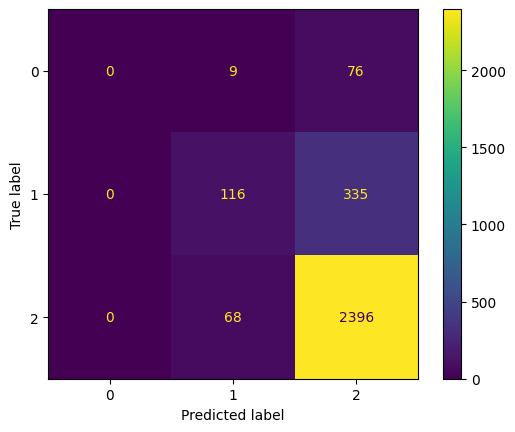

In [ ]:
#Metrics for K= 20
y_pred , report = knn_model(20 , x_train, x_test, y_train, y_test, ret_predict= True)

#confusion matrix
cm = confusion_matrix(y_test, y_pred)

#Graphical view of Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix= cm ).plot()

###KNN on the balanced sampled dataset

In [ ]:
#load the dataset
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_no_outlier_sampled_balanced.csv'

df_incident_balanced = pd.read_csv(directory, index_col= None)

In [ ]:
#splitting data
X = df_incident_balanced.drop('Offense Status', axis=1)  # Features
y = df_incident_balanced['Offense Status']  # Target variable

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#modeling the KNN
#KNN models with different K
k_values = [5,10,15,20,25,30,35,40]
for k in k_values:
    report = knn_model(k, x_train, x_test, y_train, y_test)
    print(f"Classification Report for K={k}:\n{report}\n")


Classification Report for K=5:
              precision    recall  f1-score   support

   Suspended       0.46      0.58      0.51       993
    Resolved       0.53      0.51      0.52       970
     Pending       0.58      0.46      0.51      1037

    accuracy                           0.52      3000
   macro avg       0.53      0.52      0.52      3000
weighted avg       0.53      0.52      0.52      3000


Classification Report for K=10:
              precision    recall  f1-score   support

   Suspended       0.49      0.57      0.53       993
    Resolved       0.55      0.54      0.54       970
     Pending       0.58      0.50      0.53      1037

    accuracy                           0.53      3000
   macro avg       0.54      0.53      0.53      3000
weighted avg       0.54      0.53      0.53      3000


Classification Report for K=15:
              precision    recall  f1-score   support

   Suspended       0.48      0.55      0.51       993
    Resolved       0.58      0.5

In [ ]:
#Defining a function for Stratified Sampling
def stra_train_test_split(df, column, percentage, test_size = 0.2 ):


    #Creating a dictionary with the key=column unique values and value=associated percentage
    percentage_dict = dict(zip(df[column].unique(), percentage))

    # DataFrames to store results
    train_set = pd.DataFrame()
    test_set = pd.DataFrame()

    test_size = df.shape[0] * test_size

    # Stratify sample for each category based on the percentages
    for category, percentage in percentage_dict.items():
        category_data = df[df[column] == category]

        # Calculate the number of samples for this category
        size = int(test_size * percentage)


        # Split into train and test sets
        test_category_data = category_data.iloc[:size]
        train_category_data = category_data.iloc[size:]

        # Append to train and test sets
        train_set = pd.concat([train_set, train_category_data])
        test_set = pd.concat([test_set, test_category_data])

    return train_set, test_set




In [ ]:
#Sampling based on the class column disturbution in the original dataset
percentage = [ 0.82, 0.15, 0.03 ]

#train and test split with a custom disturbution of the class column
train_set , test_set = stra_train_test_split(df_incident_balanced, 'Offense Status', percentage, test_size = 0.2)


In [ ]:
#define x_train, y_train, x_test, y_test
y_train_balanced = train_set['Offense Status']
x_train_balanced = train_set.drop('Offense Status', axis=1)

x_test_balanced = test_set.drop('Offense Status', axis=1)
y_test_balanced = test_set['Offense Status']

In [ ]:
#modeling the KNN
#KNN models with different K
k_values = [10,13,16,19,22,25,28,31]
for k in k_values:
    report = knn_model(k, x_train_balanced, x_test_balanced, y_train_balanced, y_test_balanced)
    print(f"Classification Report for K={k}:\n{report}\n")


Classification Report for K=10:
              precision    recall  f1-score   support

   Suspended       0.04      0.63      0.08        90
    Resolved       0.29      0.56      0.38       450
     Pending       0.93      0.30      0.45      2460

    accuracy                           0.35      3000
   macro avg       0.42      0.50      0.30      3000
weighted avg       0.81      0.35      0.43      3000


Classification Report for K=13:
              precision    recall  f1-score   support

   Suspended       0.05      0.68      0.08        90
    Resolved       0.30      0.58      0.40       450
     Pending       0.93      0.30      0.45      2460

    accuracy                           0.35      3000
   macro avg       0.43      0.52      0.31      3000
weighted avg       0.81      0.35      0.43      3000


Classification Report for K=16:
              precision    recall  f1-score   support

   Suspended       0.04      0.62      0.08        90
    Resolved       0.31      0.

### Defining manual sampling and train and test spliting functions

In [ ]:
#datetime binning
def date_binning(df):
      #iterating over 2 datetime column
      for col in ['Call Dispatch Date Time' , 'Call Cleared Date Time']:
          # Convert 'Call Dispatch Date Time' to datetime objects
          df[col] = pd.to_datetime(df[col])

          # Extract year and month
          df[f"{col}_Year"] = df[col].dt.year.astype(object)
          df[f"{col}_Year"] = df[col].dt.month.astype(object)


          # Create a dictionary mapping month numbers to month names
          month_dict = {i: calendar.month_name[i] for i in range(1, 13)}
          df[f"{col}_Year"] = df[f"{col}_Year"].map(month_dict)

          #dropping the original column
          df.drop(col, axis=1, inplace=True)
      return df

In [ ]:
#Defining a function for Stratified Sampling and binning
def stra_sample(df , column , sample_size = 15000 , *percentage):

    #Defining the prefixed value for percentage as 1/ number of categories in the column atrribute
    if not percentage:
        percentage = [1/df[column].nunique()  for i in range(df[column].nunique() )]


    #Creating a dictionary with the key=column unique values and value=associated percentage
    percentage_dict = dict(zip(df[column].unique(), percentage))

    df_sampled = pd.DataFrame()  # Empty DataFrame to store results

    # Stratify sample for each category based on the percentages
    for category, percentage in percentage_dict.items():
        category_data = df[df[column] == category]

        # Calculate the number of samples for this category
        size = int(sample_size * percentage)
        sampled_category_data = category_data.sample(n=size, random_state=42)
        df_sampled = pd.concat([df_sampled, sampled_category_data])

    #Binning datetime columns based on months
    df_sampled = date_binning(df_sampled)

    #one hot encoding
    # Defining Categorical Columns
    categorical_cols = df_sampled.columns
    categorical_cols = categorical_cols.drop(column)

    # Apply one-hot encoding and update the dataset in place
    df_sampled = pd.get_dummies(df_sampled, columns=categorical_cols, drop_first=True)


    return df_sampled

In [ ]:
#loading dataset before sampling
#uploading datasets
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_cleaned_without_outliers.csv'

df_incident_no_outlier = pd.read_csv(directory, index_col= None)

#### DO NOT READ - Testing the functions


In [ ]:
#DO NOT READ
#For testing purposes
#defining different percentage for sampling
perc = [0.7, 0.2, 0.1]
original_percentages = [0.82, 0.15, 0.03]
df_temp = stra_sample(df_incident_no_outlier, 'Offense Status', 15000, *perc)


In [ ]:
df_temp.head()

,Offense Status,Watch_Watch 2,Watch_Watch 3,Division_North,Division_South,Sector_120.0,Sector_130.0,Sector_140.0,Sector_150.0,Sector_210.0,...,Call Cleared Date Time_Year_December,Call Cleared Date Time_Year_February,Call Cleared Date Time_Year_January,Call Cleared Date Time_Year_July,Call Cleared Date Time_Year_June,Call Cleared Date Time_Year_March,Call Cleared Date Time_Year_May,Call Cleared Date Time_Year_November,Call Cleared Date Time_Year_October,Call Cleared Date Time_Year_September
249681,Suspended,False,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
266476,Suspended,True,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
423361,Suspended,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
452770,Suspended,True,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
274790,Suspended,True,False,True,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False


In [ ]:

#Disturbution of class column in sample
print ('sampled data w/outliers:', df_temp['Offense Status'].value_counts(normalize=True), '\n')

sampled data w/outliers: Offense Status
Suspended    0.7
Resolved     0.2
Pending      0.1
Name: proportion, dtype: float64 



In [ ]:

#train and test set
train_set , test_set = stra_train_test_split(df_temp, 'Offense Status', original_percentages, test_size = 0.2)
datasets = [train_set, test_set]

#x_train, x_test, y_train, y_test
x_train_temp = train_set.drop('Offense Status', axis=1)
y_train_temp = train_set['Offense Status']

x_test_temp= test_set.drop('Offense Status', axis=1)
y_test_temp = test_set['Offense Status']

#Printing the disturbution in train and test set
print ('train data :', y_train_temp.value_counts(normalize=True), '\n')
print ('test data :', y_test_temp.value_counts(normalize=True), '\n')

train data : Offense Status
Suspended    0.6700
Resolved     0.2125
Pending      0.1175
Name: proportion, dtype: float64 

test data : Offense Status
Suspended    0.82
Resolved     0.15
Pending      0.03
Name: proportion, dtype: float64 



In [ ]:
k= [2,3,4,6,7,8,10,12]
for k in k:
  report = knn_model(k, x_train_balanced, x_test_balanced, y_train_balanced, y_test_balanced)
  print(f"Classification Report for K={k}:\n{report}\n")


Classification Report for K=2:
              precision    recall  f1-score   support

   Suspended       0.04      0.06      0.05        90
    Resolved       0.32      0.37      0.35       450
     Pending       0.86      0.83      0.85      2460

    accuracy                           0.74      3000
   macro avg       0.41      0.42      0.41      3000
weighted avg       0.76      0.74      0.75      3000


Classification Report for K=3:
              precision    recall  f1-score   support

   Suspended       0.02      0.01      0.01        90
    Resolved       0.48      0.19      0.27       450
     Pending       0.85      0.96      0.90      2460

    accuracy                           0.81      3000
   macro avg       0.45      0.38      0.39      3000
weighted avg       0.77      0.81      0.78      3000


Classification Report for K=4:
              precision    recall  f1-score   support

   Suspended       0.03      0.01      0.02        90
    Resolved       0.39      0.35 

###Try KNN with different Sampling Disturbution

In [ ]:
#defining different percentage for sampling
perc = [[0.8, 0.15, 0.05], [0.75, 0.18, 0.07], [0.7 , 0.2 , 0.1], [0.65 , 0.23 , 0.12], [0.6, 0.25 , 0.15]]
original_percentages = [0.82, 0.15, 0.03]

k_values = [2,6,10,14]

for percentage in perc:
    #sampling with different disturbution of class
    df = stra_sample(df_incident_no_outlier, 'Offense Status', 15000, *percentage)

    #train and test set
    train_set , test_set = stra_train_test_split(df, 'Offense Status', original_percentages, test_size = 0.2)
    datasets = [train_set, test_set]

    #x_train, x_test, y_train, y_test
    x_train_balanced = train_set.drop('Offense Status', axis=1)
    y_train_balanced = train_set['Offense Status']

    x_test_balanced = test_set.drop('Offense Status', axis=1)
    y_test_balanced = test_set['Offense Status']

    print(f"percentage : {percentage} \n")

    for k in k_values:
      report = knn_model(k, x_train_balanced, x_test_balanced, y_train_balanced, y_test_balanced)
      print(f"Classification Report for K={k}:\n{report}\n")


percentage : [0.8, 0.15, 0.05] 

Classification Report for K=2:
              precision    recall  f1-score   support

   Suspended       0.06      0.14      0.09        90
    Resolved       0.32      0.37      0.35       450
     Pending       0.87      0.80      0.83      2460

    accuracy                           0.72      3000
   macro avg       0.42      0.44      0.42      3000
weighted avg       0.76      0.72      0.74      3000


Classification Report for K=6:
              precision    recall  f1-score   support

   Suspended       0.05      0.03      0.04        90
    Resolved       0.47      0.31      0.37       450
     Pending       0.86      0.93      0.89      2460

    accuracy                           0.81      3000
   macro avg       0.46      0.42      0.43      3000
weighted avg       0.78      0.81      0.79      3000


Classification Report for K=10:
              precision    recall  f1-score   support

   Suspended       0.00      0.00      0.00        90


In [ ]:
# best model
perc = [[0.75, 0.18, 0.07]]
k_values =[14]

for percentage in perc:
    #sampling with different disturbution of class
    df = stra_sample(df_incident_no_outlier, 'Offense Status', 15000, *percentage)

    #train and test set
    train_set , test_set = stra_train_test_split(df, 'Offense Status', original_percentages, test_size = 0.2)
    datasets = [train_set, test_set]

    #x_train, x_test, y_train, y_test
    x_train_balanced = train_set.drop('Offense Status', axis=1)
    y_train_balanced = train_set['Offense Status']

    x_test_balanced = test_set.drop('Offense Status', axis=1)
    y_test_balanced = test_set['Offense Status']

    print(f"percentage : {percentage} \n")

    for k in k_values:
      y_pred , report = knn_model(k, x_train_balanced, x_test_balanced, y_train_balanced, y_test_balanced, ret_predict= True)
      print(f"Classification Report for K={k}:\n{report}\n")



percentage : [0.75, 0.18, 0.07] 

Classification Report for K=14:
              precision    recall  f1-score   support

   Suspended       0.14      0.02      0.04        90
    Resolved       0.51      0.34      0.41       450
     Pending       0.86      0.94      0.90      2460

    accuracy                           0.82      3000
   macro avg       0.50      0.44      0.45      3000
weighted avg       0.79      0.82      0.80      3000


train data : Offense Status
Suspended    0.7325
Resolved     0.1875
Pending      0.0800
Name: proportion, dtype: float64 

test data : Offense Status
Suspended    0.82
Resolved     0.15
Pending      0.03
Name: proportion, dtype: float64 



The Best result happens for the sampling of the disturbution of : [0.75, 0.18, 0.07]

####Saving the best  dataset further use in TREE models

In [ ]:
#saving x_train, y_train, x_test, y_test
main_directory = '/content/drive/My Drive/Algonquin/Machine Learning Project/Best sampling Dis/'

x_train_balanced.to_csv(main_directory + 'x_train.csv', index=False)
x_test_balanced.to_csv(main_directory + 'x_test.csv', index=False)
y_train_balanced.to_csv(main_directory + 'y_train.csv', index=False)
y_test_balanced.to_csv(main_directory + 'y_test.csv', index=False)

###Finding the best K for the dataset with best disturbution

In [ ]:
#Loading x_train, y_train, x_test, y_test
main_directory = '/content/drive/My Drive/Algonquin/Machine Learning Project/Best sampling Dis/'
x_train = pd.read_csv(main_directory + 'x_train.csv',index_col= None)
x_test = pd.read_csv(main_directory + 'x_test.csv',index_col= None)
y_train = pd.read_csv(main_directory + 'y_train.csv',index_col= None)
y_test = pd.read_csv(main_directory + 'y_test.csv',index_col= None)


In [ ]:
#trying different Ks for the model
k_values = [12,16,18,20,22]
for k in k_values:
    report = knn_model(k, x_train, x_test, y_train, y_test)
    print(f"Classification Report for K={k}:\n{report}\n")

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Classification Report for K=12:
              precision    recall  f1-score   support

   Suspended       0.10      0.03      0.05        90
    Resolved       0.49      0.33      0.40       450
     Pending       0.87      0.94      0.90      2460

    accuracy                           0.82      3000
   macro avg       0.49      0.43      0.45      3000
weighted avg       0.79      0.82      0.80      3000




/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Classification Report for K=16:
              precision    recall  f1-score   support

   Suspended       0.18      0.02      0.04        90
    Resolved       0.51      0.35      0.41       450
     Pending       0.87      0.95      0.90      2460

    accuracy                           0.83      3000
   macro avg       0.52      0.44      0.45      3000
weighted avg       0.79      0.83      0.80      3000




/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Classification Report for K=18:
              precision    recall  f1-score   support

   Suspended       0.20      0.02      0.04        90
    Resolved       0.52      0.34      0.41       450
     Pending       0.86      0.95      0.90      2460

    accuracy                           0.83      3000
   macro avg       0.53      0.44      0.45      3000
weighted avg       0.79      0.83      0.80      3000




/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Classification Report for K=20:
              precision    recall  f1-score   support

   Suspended       0.17      0.01      0.02        90
    Resolved       0.52      0.34      0.41       450
     Pending       0.86      0.95      0.91      2460

    accuracy                           0.83      3000
   macro avg       0.52      0.43      0.45      3000
weighted avg       0.79      0.83      0.80      3000




/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Classification Report for K=22:
              precision    recall  f1-score   support

   Suspended       0.00      0.00      0.00        90
    Resolved       0.52      0.33      0.40       450
     Pending       0.86      0.95      0.90      2460

    accuracy                           0.83      3000
   macro avg       0.46      0.43      0.44      3000
weighted avg       0.79      0.83      0.80      3000




/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Classification Report for K=18:
              precision    recall  f1-score   support

   Suspended       0.20      0.02      0.04        90
    Resolved       0.52      0.34      0.41       450
     Pending       0.86      0.95      0.90      2460

    accuracy                           0.83      3000
   macro avg       0.53      0.44      0.45      3000
weighted avg       0.79      0.83      0.80      3000




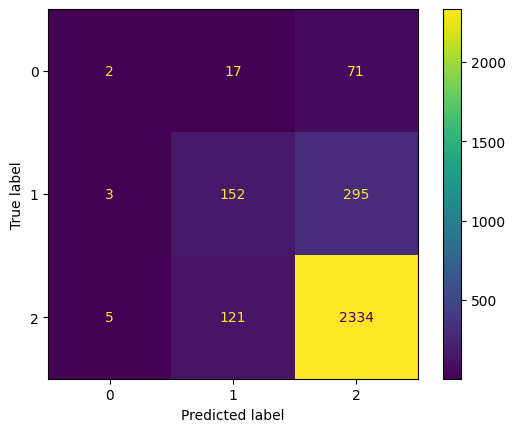

In [ ]:
#Confusion matrix for the best model
k=18
y_pred , report = knn_model(k, x_train, x_test, y_train, y_test, ret_predict= True)

print(f"Classification Report for K={k}:\n{report}\n")
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

#Graphical view of Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix= cm ).plot()

##Decision Tree

Decision tree with no outliers sampled dataset

In [ ]:
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_no_outlier_sampled.csv'
Decisiontree = pd.read_csv(file_path)

In [ ]:
#splitting data into training and test set
DX = Decisiontree.drop(columns=['Offense Status'])
DY = Decisiontree['Offense Status']

DXtrain, DXtest, DYtrain, DYtest = train_test_split(DX, DY, test_size=0.2, random_state=42)

In [ ]:
#defining decision tree model
dt_model = DecisionTreeClassifier(random_state=42)

In [ ]:
#Defining parameter grid for GridSearch
param_g = {'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'splitter': ['best', 'random'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]}

In [ ]:
grid = GridSearchCV(estimator=dt_model, param_grid=param_g, cv=5, scoring='accuracy', verbose=1)

In [ ]:
grid.fit(DXtrain, DYtrain)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='accuracy', verbose=1)

In [ ]:
print("Best Parameters:")
print(grid.best_params_)
print(f"Best Accuracy: {grid.best_score_:.2f}")

In [ ]:
#defining parameters and fitting the model
dtree = DecisionTreeClassifier(max_depth=4, min_samples_split=4,min_samples_leaf=2, criterion='gini',splitter='best' )
dtree.fit(DXtrain, DYtrain)

In [ ]:
#creatind predicting class
DYpred = dtree.predict(DXtest)

In [ ]:
#plotting the tree
plt.figure(figsize=(40,10))
plot_tree(dtree, filled=True, rounded=True)
plt.show()

In [ ]:
#checking accuracy of the model
accuracy = accuracy_score(DYtest, DYpred)
print("Accuracy:", accuracy)

In [ ]:
#checking classification report
classification_rep = classification_report(DYtest, DYpred)
print("Classification Report:\n", classification_rep)

In [ ]:
#checking confusion matrix
confusionm = confusion_matrix(DYtest, DYpred)

print("Confusion Matrix:\n", confusionm)


plt.figure(figsize=(6,4))
sns.heatmap(confusionm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

Random Forest with no outliers sampled dataset

In [ ]:
#Initialising Random Forest
random_forest = RandomForestClassifier(n_estimators=150, random_state=42, max_depth=15, min_samples_leaf=5,min_samples_split=15)
random_forest.fit(DXtrain, DYtrain)

In [ ]:
DYpred = random_forest.predict(DXtest)

In [ ]:
#Checking accuracy
accuracy = accuracy_score(DYtest, DYpred)
print("Accuracy:", accuracy)

In [ ]:
#Checking classification
classification_rep = classification_report(DYtest, DYpred)
print("Classification Report:\n", classification_rep)

**Decision Tree with best split after sampling**

In [ ]:
#loading training and test sets
main_directory = '/content/drive/My Drive/Algonquin/Machine Learning Project/Best sampling Dis/'
x_train = pd.read_csv(main_directory + 'x_train.csv',index_col= None)
x_test = pd.read_csv(main_directory + 'x_test.csv',index_col= None)
y_train = pd.read_csv(main_directory + 'y_train.csv',index_col= None)
y_test = pd.read_csv(main_directory + 'y_test.csv',index_col= None)

In [ ]:
#defining decision tree model
dt_model = DecisionTreeClassifier(random_state=42)

In [ ]:
#Defining parameter grid for GridSearch
param_g = {'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'splitter': ['best', 'random'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]}

In [ ]:
grid = GridSearchCV(estimator=dt_model, param_grid=param_g, cv=5, scoring='accuracy', verbose=1)

In [ ]:
grid.fit(x_train, y_train)

In [ ]:
#checking what is the best possible parameter for us
print("Best Parameters:")
print(grid.best_params_)
print(f"Best Accuracy: {grid.best_score_:.2f}")

In [ ]:
#defining parameters and fitting the model
dtree = DecisionTreeClassifier(max_depth=4, min_samples_split=4,min_samples_leaf=2, criterion='gini',splitter='best' )
dtree.fit(x_train, y_train)

In [ ]:
#creatind predicting class
Dypred = dtree.predict(x_test)

In [ ]:
#plotting the tree
plt.figure(figsize=(40,10))
plot_tree(dtree, filled=True, rounded=True)
plt.show()

In [ ]:
#checking accuracy of the model
accuracy = accuracy_score(y_test, Dypred)
print("Accuracy:", accuracy)

In [ ]:
#checking classification report
classification_rep = classification_report(y_test, Dypred)
print("Classification Report:\n", classification_rep)

In [ ]:
#plotting and checking confusion matrix
cm = confusion_matrix(y_test, Dypred)

print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

Random forest with best split after sampling


In [ ]:
#training random forest classifer
random_forest = RandomForestClassifier(n_estimators=150, random_state=42, max_depth=15, min_samples_leaf=5,min_samples_split=15)
random_forest.fit(x_train, y_train)

In [ ]:
y_pred = random_forest.predict(x_test)

In [ ]:
#checking accuracy for random forest
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

In [ ]:
#checking classification report for random forest
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_rep)

##K-Means


In [ ]:
#uploading the dataset
directory= '/content/drive/My Drive/Algonquin/Machine Learning Project/df_incident_no_outlier_sampled.csv'

df_incident_no_outlier_sampled = pd.read_csv(directory, index_col= None)

In [ ]:
#one hot encoding for offense status
df_incident_no_outlier_sampled = pd.get_dummies(df_incident_no_outlier_sampled, columns=['Offense Status'], drop_first=True)

Text(0.5, 1.0, 'Elbow Method for Optimal k, (K = 150)')

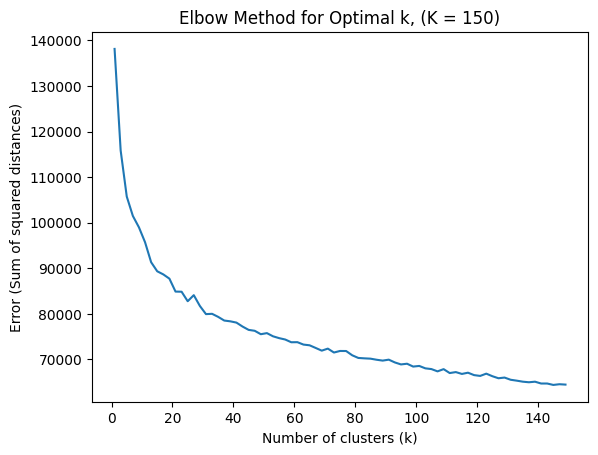

In [ ]:
# Range of k values to try
k_values = range(1, 150 , 2)
k_error = []



# Calculate inertia for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_incident_no_outlier_sampled)
    k_error.append(kmeans.inertia_)


# Plot the elbow graph
plt.figure()
plt.plot(k_values, k_error)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Error (Sum of squared distances)')
plt.title('Elbow Method for Optimal k, (K = 150)')


##Outlier Detection (LOF & ISF)

Import dataset

In [ ]:
data = pd.read_csv('dallas_df_isf.csv')

isf_df = pd.DataFrame(data)
lof_df = pd.DataFrame(data)



Checking for correct datatypes (must be Numerical)

In [ ]:
# print('Sector max value:', max(isf_df['Sector']), 'Sector min value:', min(isf_df['Sector']))
# print('Call Duaration (Minutes) max value:', max(isf_df['Call Duration (Minutes)']), 'Call Duaration (Minutes) min value:', min(isf_df['Call Duration (Minutes)']))
# # Show all data types in a scrollable element
# data_types_html = isf_df.dtypes.to_frame(name='Data Type').to_html(escape=False)
# HTML(f'<div style="overflow-y: auto; max-height: 300px;">{data_types_html}</div>')

### ISF (diastance based)

Use a subset of data to make the code run faster
* Using 5% (~20,000 rows) of imported data

In [ ]:
isf_df_sample = resample(isf_df, n_samples=int(len(isf_df)*0.05), random_state=42,)

Use PCA to reduce feature space, improves runtime duration, and model performance

In [ ]:
pca = PCA(n_components=20)  # Reduce to 50 columns (originally 155 columns after one-hot encoding)
isf_df_sample_reduced = pd.DataFrame(pca.fit_transform(isf_df_sample))


Create model and optimize parameters (Grid Search CV)
* n_estimators: Number of base estimators in the ensemble
* max-samples: Number of samples in each estimator
* Contamination: Proportion outliers in the dataset
* max_features: Number of features in each estimator
* random state: For reroducability of psuedo-randomness
* Bootstrap: Data is sampled with replacement. For more info, lookup what is bootstrapping in Isolation Forest

Below parameters can be adjust to explore more combninations

In [ ]:
# Define parameter grid for Isolation Forest (Using a smaller set of values to make algorithm run faster)
param_grid = {
    'n_estimators': [100, 200, 300],     # Number of ensemble trees
    'max_samples': [0.1, 0.2, 0.3],      # Number of samples to use for training during each ensemble ('auto' = 256 samples)
    'contamination': [0.05, 0.10, 0.15], # Expected outlier proportion
    'max_features': [0.6, 0.7, 0.8],     # Number of features to consider during each ensemble
    'bootstrap': [False]                 # Bootstrap sampling (True is better, but computationally expensive)
}

Create a custom scoring function:
* Using Mean anomaly score - for ranking performance of each combination of parameters
* All rows are assigned an anamoly score between -1, 1.
* Calculate the mean of the anamoly scores
* Lower scores mean less anamolies, better performing model

In [ ]:
# Custom scoring function: Mean anomaly score
    # Parameters:
    # - estimator: The trained Isolation Forest model.
    # - X: The dataset to evaluate.

def mean_anomaly_score(estimator, isf_df_sample_reduced):
    scores = estimator.decision_function(isf_df_sample_reduced)  # Higher scores are less anomalous
    mean_score = -np.mean(scores)         # Negate to align with scoring metrics (lower is better)
    return mean_score


Initialize RandomizedSearchCV
* Set a single k-folds value for cross-validation ('cv')

In [ ]:

randomized_search = RandomizedSearchCV(
    estimator=IsolationForest(random_state=42),
    n_iter = 10,                 # Number of parameter combinations to test (choose a lower value to run faster)
    param_distributions=param_grid,       # Eavluate over the parameter range set above
    scoring=mean_anomaly_score,  # Use custom scorer defined above
    cv=3,                        # Cross-validation (number of k-folds), choose a lower value for faster runtime
    n_jobs=-1,                   # -1 to utilize all CPU cores
    verbose=2                    # Controls amount of information displayed during execution
)
randomized_search.fit(isf_df_sample_reduced)

best_overall_isf_model = randomized_search.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits


Output the best results for RandomizedSearchCV

In [ ]:
# Output best parameters and the best model
print("Best Parameters:", randomized_search.best_params_)
print("Best Mean Anomaly Score (-1 => outlier, 1 for inliner):", randomized_search.best_score_)

Best Parameters: {'n_estimators': 300, 'max_samples': 0.3, 'max_features': 0.8, 'contamination': 0.15, 'bootstrap': False}
Best Mean Anomaly Score (-1 => outlier, 1 for inliner): -0.03151505715597341


Predict Outliers
* Training is now complete for ISF model on the above dataset
* The trained ISF model can now be applied to any similar datsets to predict outliers


In [ ]:
# Predict outliers
# 'X' can be replaced with any similar dataset, doesn't have to be same from from above
X = isf_df_sample_reduced
isf_outliers = best_overall_isf_model.fit_predict(X)

# Print the number of outliers detected by Isolation Forest
print('Number of outliers with ISF:', len(isf_df_sample_reduced[isf_outliers == -1]))

Number of outliers with ISF: 3538


### LOF
* Similar process to ISF
* Different set of parameters
    * n_neighbours: The number of nearest neighbors used to compute the local density of a data point.
    * leaf_size: The size of leaf nodes in the KD-tree or Ball-tree used for efficient neighbor searches.
    * metric: The distance metric used to compute distances between data points.
    * p: The power parameter for the Minkowski metric.
    * contamination: The proportion of outliers in the dataset.
    * algorithm: he algorithm used to compute nearest neighbors.


In [ ]:
lof_df_sample = resample(lof_df, n_samples=int(len(lof_df)*0.05), random_state=42,)

pca = PCA(n_components=20)  # Reduce to 50 columns (originally 155 columns after one-hot encoding)
lof_df_sample_reduced = pd.DataFrame(pca.fit_transform(lof_df_sample))

# Define parameter grid for  LOF (Using a smaller set of values to make algorithm run faster)
param_grid = {
    "n_neighbors": randint(5, 50),                      # Randomly select between 5 and 50 neighbors
    "leaf_size": randint(20, 50),                       # Randomly choose leaf sizes from 20 to 50
    "metric": ["euclidean", "manhattan", "minkowski"],  # Common distance metrics
    "p": uniform(1, 2),                                 # Minkowski metric's power parameter, typically between 1 (Manhattan) and 2 (Euclidean)
    "contamination": uniform(0.01, 0.1),                # Expected proportion of outliers (1% to 10%)
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],  # Search algorithm
}

# Custom scoring function: Mean anomaly score
    # Parameters:
    # - estimator: The trained Isolation Forest model.
    # - X: The dataset to evaluate.

def mean_anomaly_score(estimator, lof_df_sample_reduced):
    scores = estimator.decision_function(lof_df_sample_reduced)  # Higher scores are less anomalous
    mean_score = -np.mean(scores)         # Negate to align with scoring metrics (lower is better)
    return mean_score

# Initialize LOF in novelty detection mode
lof = LocalOutlierFactor(novelty=True)

randomized_search = RandomizedSearchCV(
    estimator=lof,
    n_iter = 10,                 # Number of parameter combinations to test (choose a lower value to run faster)
    param_distributions=param_grid,       # Eavluate over the parameter range set above
    scoring=mean_anomaly_score,  # Use custom scorer defined above
    cv=3,                        # Cross-validation (number of k-folds), choose a lower value for faster runtime
    n_jobs=-1,                   # -1 to utilize all CPU cores
    verbose=2                    # Controls amount of information displayed during execution
)
randomized_search.fit(lof_df_sample_reduced)

best_overall_lof_model = randomized_search.best_estimator_

# Output best parameters and the best model
print("Best LOF Parameters:", randomized_search.best_params_)
print("Best LOF Mean Anomaly Score (-1 => outlier, 1 for inliner):", randomized_search.best_score_)

# Predict outliers
# 'X' can be replaced with any similar dataset, doesn't have to be same from from above
X = lof_df_sample_reduced
lof_outliers = best_overall_lof_model.predict(X)

# Print the number of outliers detected by Isolation Forest
print('Number of outliers with LOF:', len(lof_df_sample_reduced[lof_outliers == -1]))




Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best LOF Parameters: {'algorithm': 'ball_tree', 'contamination': np.float64(0.0892888012193911), 'leaf_size': 45, 'metric': 'euclidean', 'n_neighbors': 46, 'p': np.float64(1.5079829364880142)}
Best LOF Mean Anomaly Score (-1 => outlier, 1 for inliner): -0.08255011015724024
Number of outliers with ISF: 2015
